# IBM HR Analytics : Employee Attrition & Performance

### Import Libraries

In [ ]:
import sys
print(sys.executable)
print(sys.version)

In [7]:
# install/check packages:
# %pip install pandas numpy matplotlib seaborn scikit-learn category_encoders kaggle

In [ ]:
import pandas as pd

import numpy as np

# pathlib = safe file path handling
from pathlib import Path

# matplotlib and seaborn = visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# warnings = hide unnecessary technical warnings
import warnings
warnings.filterwarnings("ignore")

# Show more columns/rows when displaying tables
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Show decimal numbers in a cleaner way
pd.set_option("display.float_format", "{:.3f}".format)

# Set a professional chart style
sns.set_theme(style="whitegrid", context="notebook")

# Default chart size
plt.rcParams["figure.figsize"] = (10, 5)

# Make chart titles bold
plt.rcParams["axes.titleweight"] = "bold"

# Random state keeps random results reproducible
RANDOM_STATE = 42

### Load the dataset

In [9]:
# The dataset is stored inside the local data folder
csv_path = Path("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Check whether Python can find the file
print("File exists:", csv_path.exists())

# Load CSV file into a pandas DataFrame
df_raw = pd.read_csv(csv_path)

# Print dataset size
print("Rows and columns:", df_raw.shape)

# Show first 5 rows
df_raw.head()

File exists: True
Rows and columns: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### Understand Dataset

In [10]:
# Display the first 5 rows
display(df_raw.head())

# Display the last 5 rows
display(df_raw.tail())

# Display all column names
df_raw.columns.tolist()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
# Step 4: Check data types and missing values

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Data quality summary

In [12]:
quality_summary = pd.DataFrame({
    "data_type": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_percent": df_raw.isna().mean() * 100,
    "unique_values": df_raw.nunique()
})

# Sort the table so suspicious columns appear clearly
quality_summary = quality_summary.sort_values(
    by=["missing_count", "unique_values"],
    ascending=[False, True]
)

quality_summary

,data_type,missing_count,missing_percent,unique_values
EmployeeCount,int64,0,0.000,1
Over18,object,0,0.000,1
StandardHours,int64,0,0.000,1
Attrition,object,0,0.000,2
Gender,object,0,0.000,2
OverTime,object,0,0.000,2
PerformanceRating,int64,0,0.000,2
BusinessTravel,object,0,0.000,3
Department,object,0,0.000,3
MaritalStatus,object,0,0.000,3


<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>🧹 Conclusion: Initial Data Quality Check</h2>

<p>The initial data quality check showed that the dataset is clean and ready for the next analysis steps.</p>

</div>

---

## ✅ Missing Values Check

The dataset contains **no missing values**.

This means we do not need to fill, replace, or remove missing values at this stage.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #22c55e; border-radius:8px;">

<h3>✅ Key Data Quality Finding</h3>

<p>No missing values were found in the dataset.</p>

<p>This reduces the need for data cleaning before exploratory analysis.</p>

</div>

---

## 🗑️ Removed Unnecessary Columns

Three columns contained only **one unique value** for all employees:

* `EmployeeCount`
* `Over18`
* `StandardHours`

These columns are not useful for machine learning because they do not create any difference between employees.

Since a model learns from differences in the data, these constant columns were removed.

---

## 🆔 Employee ID Column

The column `EmployeeNumber` was also removed because it is an employee ID.

It identifies each employee, but it does not describe employee behavior, satisfaction, income, overtime, or work history.

Therefore, it should not be used for prediction.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>⚠️ Why These Columns Were Removed</h3>

<p>Constant columns and ID columns do not provide useful predictive information.</p>

<p>Keeping them may add noise or unnecessary complexity to the model.</p>

</div>

---

## 🎯 Target Column Preparation

The target column for this project is:

```python
Attrition
```

This column tells us whether an employee **left the company** or **stayed**.

Since machine learning models work better with numbers, `Attrition` was converted from text into numeric form.

| Original Value | Numeric Value | Meaning         |
| -------------- | ------------: | --------------- |
| `Yes`          |         **1** | Employee left   |
| `No`           |         **0** | Employee stayed |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #a855f7; border-radius:8px;">

<h3>🔢 Encoding Summary</h3>

<p><strong>Yes</strong> was converted to <strong>1</strong>, meaning the employee left.</p>

<p><strong>No</strong> was converted to <strong>0</strong>, meaning the employee stayed.</p>

</div>

---

## ✅ Final Takeaway

After removing unnecessary columns and encoding the target variable, the cleaned dataset is ready for:

* Exploratory data analysis
* Feature preprocessing
* Machine learning model development


In [14]:
# Create clean working dataset


# Start from the original loaded dataset
df_clean = df_raw.copy()

# These columns are removed because they are not useful for prediction
columns_to_drop = [
    "EmployeeCount",    # Same value for every employee
    "Over18",           # Same value for every employee
    "StandardHours",    # Same value for every employee
    "EmployeeNumber"    # ID column, not employee behavior
]

# Only drop columns that exist in the dataset
existing_columns_to_drop = [
    column for column in columns_to_drop
    if column in df_clean.columns
]

# Drop the selected columns
df_clean = df_clean.drop(columns=existing_columns_to_drop)

# Convert target column from text to number
# Yes = employee left = 1
# No = employee stayed = 0
df_clean["Attrition"] = df_clean["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print("Dropped columns:", existing_columns_to_drop)
print("df_clean created successfully.")
print("Shape of df_clean:", df_clean.shape)

df_clean.head()

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean created successfully.
Shape of df_clean: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


# Part 2 | EDA

In [15]:

# Step 10: Check attrition distribution

attrition_counts = df_clean["Attrition"].value_counts().rename(index={
    0: "Stayed",
    1: "Left"
})

attrition_rate = df_clean["Attrition"].mean() * 100

print("Attrition counts:")
display(attrition_counts)

print(f"Attrition rate: {attrition_rate:.2f}%")

Attrition counts:


Attrition
Stayed    1233
Left       237
Name: count, dtype: int64

Attrition rate: 16.12%


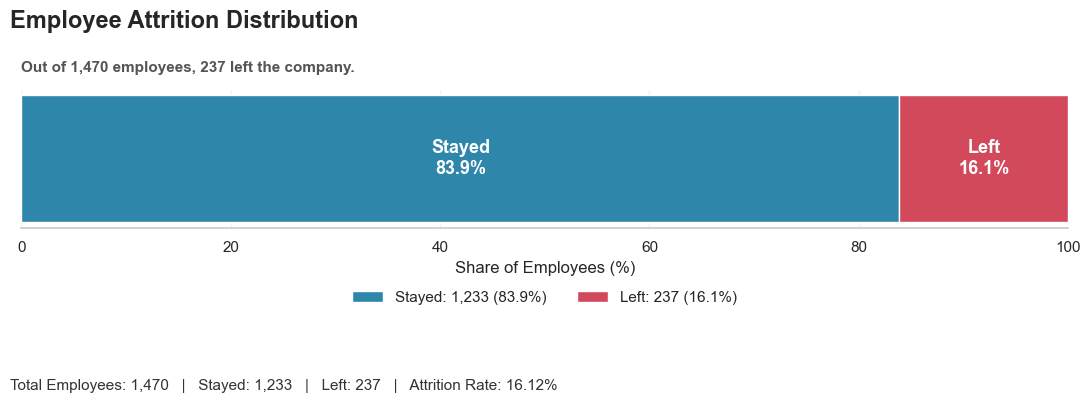

In [18]:

# Step 11: Attrition distribution

# Calculate key numbers
total_employees = len(df_clean)
employees_left = int(df_clean["Attrition"].sum())
employees_stayed = total_employees - employees_left

attrition_rate = employees_left / total_employees * 100
retention_rate = employees_stayed / total_employees * 100

# Create figure
fig, ax = plt.subplots(figsize=(11, 3.8))

# Colors
stayed_color = "#2E86AB"   # professional blue
left_color = "#D1495B"     # professional red

# Horizontal stacked bar
ax.barh(
    y=["Employees"],
    width=retention_rate,
    color=stayed_color,
    label=f"Stayed: {employees_stayed:,} ({retention_rate:.1f}%)"
)

ax.barh(
    y=["Employees"],
    width=attrition_rate,
    left=retention_rate,
    color=left_color,
    label=f"Left: {employees_left:,} ({attrition_rate:.1f}%)"
)

# Add percentage labels inside the bar
ax.text(
    retention_rate / 2,
    0,
    f"Stayed\n{retention_rate:.1f}%",
    ha="center",
    va="center",
    color="white",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    retention_rate + attrition_rate / 2,
    0,
    f"Left\n{attrition_rate:.1f}%",
    ha="center",
    va="center",
    color="white",
    fontsize=13,
    fontweight="bold"
)

# Title and subtitle
fig.suptitle(
    "Employee Attrition Distribution",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    f"Out of {total_employees:,} employees, {employees_left:,} left the company.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# KPI text below
kpi_text = (
    f"Total Employees: {total_employees:,}   |   "
    f"Stayed: {employees_stayed:,}   |   "
    f"Left: {employees_left:,}   |   "
    f"Attrition Rate: {attrition_rate:.2f}%"
)

fig.text(
    0.01,
    -0.02,
    kpi_text,
    fontsize=11,
    color="#333333"
)

# Clean formatting
ax.set_xlim(0, 100)
ax.set_xlabel("Share of Employees (%)")
ax.set_ylabel("")
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>📊 Conclusion: Attrition Distribution</h2>

<p>The dataset contains <strong>1,470 employees</strong> in total.</p>

<p>Out of these, <strong>1,233 employees stayed</strong> and <strong>237 employees left</strong> the company.</p>

</div>

---

## 📌 Attrition Summary

| Employee Status |     Count |
| --------------- | --------: |
| Stayed          | **1,233** |
| Left            |   **237** |
| Total           | **1,470** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>⚠️ Important Class Imbalance Finding</h3>

<p>The attrition rate is <strong>16.12%</strong>.</p>

<p>In simple terms, around <strong>16 out of every 100 employees</strong> left the company.</p>

</div>

---

## 🧠 Why This Matters for Machine Learning

The target variable is **imbalanced** because the number of employees who stayed is much larger than the number of employees who left.

This is important because a machine learning model could achieve high accuracy by mostly predicting that employees will stay.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Modeling Risk</h3>

<p>Accuracy alone may be misleading for this project.</p>

<p>A model could look good on accuracy while still failing to correctly identify employees who are likely to leave.</p>

</div>

---

## ✅ Evaluation Strategy

For model evaluation, we should not rely only on accuracy.

Instead, we will also use more professional evaluation metrics:

* **Precision**
* **Recall**
* **F1-score**
* **ROC-AUC**
* **PR-AUC**

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #22c55e; border-radius:8px;">

<h3>✅ Final Takeaway</h3>

<p>Because the dataset is imbalanced, model performance should be evaluated using multiple metrics, especially <strong>recall, F1-score, ROC-AUC, and PR-AUC</strong>.</p>

</div>


,OverTime,employees,employees_left,attrition_rate,attrition_rate_percent
0,No,1054,110,0.104,10.436
1,Yes,416,127,0.305,30.529


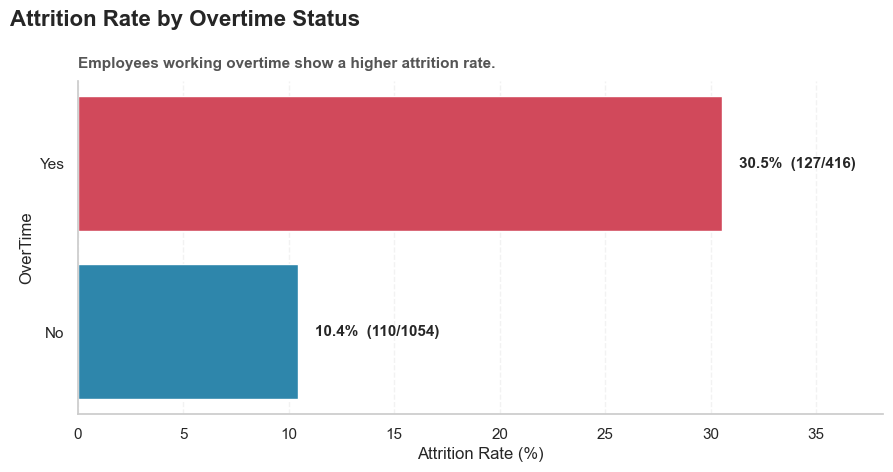

In [19]:
# Step 12: Attrition rate by OverTime


# Calculate attrition rate for each OverTime group
overtime_summary = (
    df_clean
    .groupby("OverTime")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
overtime_summary["attrition_rate_percent"] = overtime_summary["attrition_rate"] * 100

# Sort by attrition rate
overtime_summary = overtime_summary.sort_values(
    "attrition_rate_percent",
    ascending=True
)

display(overtime_summary)

# Create professional horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.barh(
    overtime_summary["OverTime"],
    overtime_summary["attrition_rate_percent"],
    color=["#2E86AB", "#D1495B"]
)

# Add labels at the end of bars
for bar, rate, left_count, total_count in zip(
    bars,
    overtime_summary["attrition_rate_percent"],
    overtime_summary["employees_left"],
    overtime_summary["employees"]
):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  ({left_count}/{total_count})",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Overtime Status",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Employees working overtime show a higher attrition rate.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=10
)

# Axis formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("OverTime")
ax.set_xlim(0, overtime_summary["attrition_rate_percent"].max() * 1.25)

# Clean formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #ef4444; border-radius:8px;">

<h2>⏰ Conclusion: Attrition Rate by Overtime</h2>

<p>Employees who work <strong>overtime</strong> show a much higher attrition rate than employees who do not work overtime.</p>

</div>

---

## 📊 Attrition Summary by Overtime

| Overtime Status | Employees Who Left | Total Employees | Attrition Rate |
| --------------- | -----------------: | --------------: | -------------: |
| No overtime     |            **110** |       **1,054** |      **10.4%** |
| Overtime        |            **127** |         **416** |      **30.5%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>The attrition rate for employees working overtime is almost <strong>three times higher</strong> than for employees who do not work overtime.</p>

<p>This suggests that <code>OverTime</code> is an important variable for understanding and predicting employee attrition.</p>

</div>

---

## 🧠 Business Interpretation

Employees working overtime may experience:

* Higher workload
* Increased stress
* Poorer work-life balance
* Lower recovery time
* Higher risk of burnout

This may explain why overtime employees show a higher attrition rate.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Note</h3>

<p>This result should be interpreted as an <strong>association</strong>, not direct proof that overtime alone causes attrition.</p>

<p>Other factors may also influence employee attrition, such as:</p>

<ul>
<li>Job role</li>
<li>Salary</li>
<li>Job satisfaction</li>
<li>Department</li>
<li>Work-life balance</li>
</ul>

</div>

---

## ✅ Final Takeaway

`OverTime` appears to be one of the most important business signals related to employee attrition.

HR teams should monitor overtime workload carefully and investigate whether excessive overtime is contributing to higher employee turnover.


,BusinessTravel,employees,employees_left,attrition_rate,attrition_rate_percent
0,Non-Travel,150,12,0.080,8.000
2,Travel_Rarely,1043,156,0.150,14.957
1,Travel_Frequently,277,69,0.249,24.910


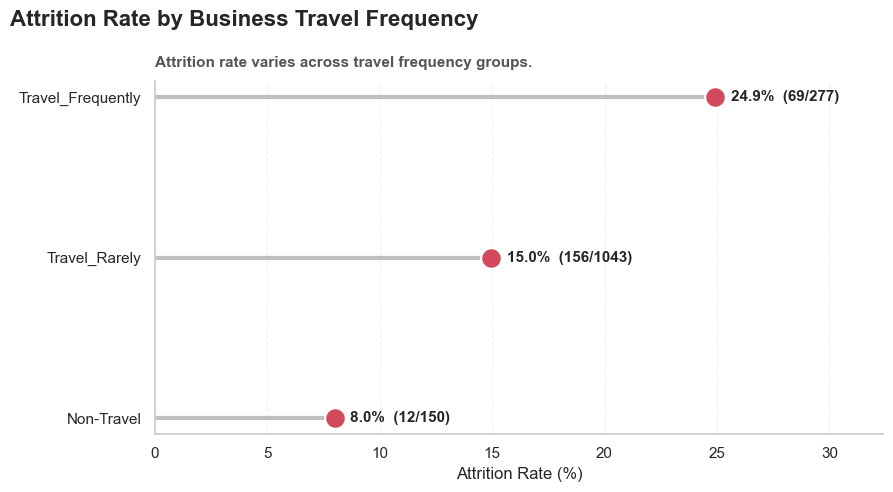

In [20]:

# Step 13: Attrition rate by Business Travel


# Calculate attrition summary by BusinessTravel group
travel_summary = (
    df_clean
    .groupby("BusinessTravel")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
travel_summary["attrition_rate_percent"] = travel_summary["attrition_rate"] * 100

# Sort by attrition rate
travel_summary = travel_summary.sort_values(
    "attrition_rate_percent",
    ascending=True
)

display(travel_summary)

# Create lollipop chart
fig, ax = plt.subplots(figsize=(9, 5))

# Horizontal lines
ax.hlines(
    y=travel_summary["BusinessTravel"],
    xmin=0,
    xmax=travel_summary["attrition_rate_percent"],
    color="#B0B0B0",
    linewidth=3,
    alpha=0.8
)

# Dots at the end
ax.scatter(
    travel_summary["attrition_rate_percent"],
    travel_summary["BusinessTravel"],
    s=220,
    color="#D1495B",
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# Add labels
for _, row in travel_summary.iterrows():
    ax.text(
        row["attrition_rate_percent"] + 0.7,
        row["BusinessTravel"],
        f"{row['attrition_rate_percent']:.1f}%  ({int(row['employees_left'])}/{int(row['employees'])})",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Business Travel Frequency",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Attrition rate varies across travel frequency groups.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=10
)

# Formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, travel_summary["attrition_rate_percent"].max() * 1.30)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #f97316; border-radius:8px;">

<h2>✈️ Conclusion: Attrition Rate by Business Travel</h2>

<p>Employees who <strong>travel frequently</strong> show the <strong>highest attrition rate</strong>.</p>

</div>

---

## 📊 Attrition Rate by Travel Frequency

| Business Travel Category | Attrition Rate |
| ------------------------ | -------------: |
| No travel                |       **8.0%** |
| Travel rarely            |      **15.0%** |
| Travel frequently        |      **24.9%** |

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>The attrition rate increases as business travel frequency increases.</p>

<p>Employees who travel frequently have an attrition rate of <strong>24.9%</strong>, which is more than three times higher than employees who do not travel.</p>

</div>

---

## 🧠 Business Interpretation

This suggests that **business travel frequency may be related to employee attrition**.

Employees who travel frequently may experience:

* Higher workload
* More stress
* Poorer work-life balance
* Less recovery time between trips
* Reduced job satisfaction

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Note</h3>

<p>This result should be interpreted as an <strong>association</strong>, not direct proof that business travel alone causes attrition.</p>

<p>Other variables may also influence attrition, such as:</p>

<ul>
<li>Overtime</li>
<li>Job role</li>
<li>Department</li>
<li>Monthly income</li>
<li>Job satisfaction</li>
<li>Environment satisfaction</li>
</ul>

</div>

---

## ✅ Final Takeaway

Business travel appears to be an important attrition-related factor.

HR teams should pay closer attention to employees who travel frequently and investigate whether travel expectations, workload, or work-life balance are contributing to higher employee turnover.


,Department,employees,employees_left,attrition_rate,attrition_rate_percent
0,Sales,446,92,0.206,20.628
1,Human Resources,63,12,0.190,19.048
2,Research & Development,961,133,0.138,13.840


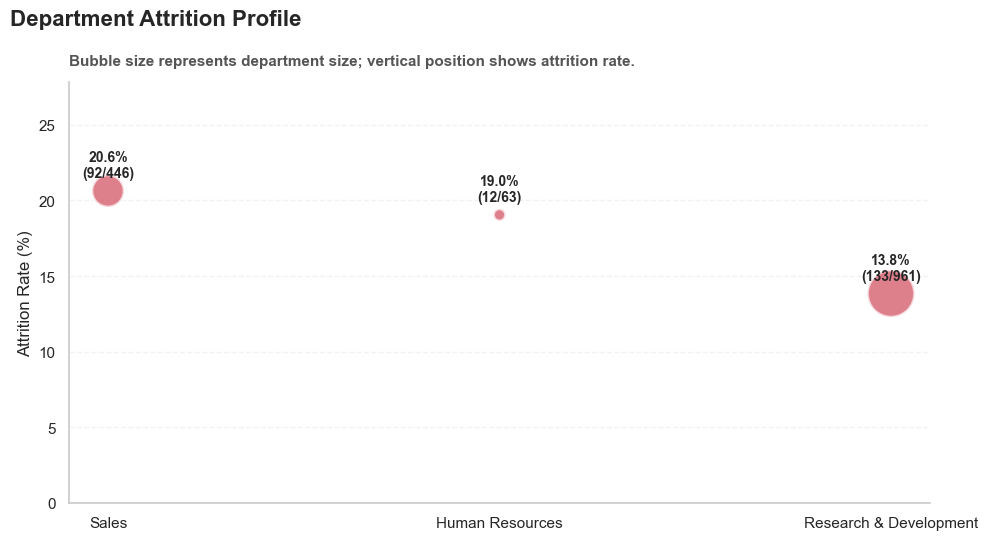

In [ ]:

# Step 14: Department analysis — Attrition rate and department size


# Calculate department-level summary
department_summary = (
    df_clean
    .groupby("Department")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
department_summary["attrition_rate_percent"] = department_summary["attrition_rate"] * 100

# Sort by attrition rate for storytelling
department_summary = department_summary.sort_values(
    "attrition_rate_percent",
    ascending=False
).reset_index(drop=True)

display(department_summary)

# Bubble size shows department size
bubble_size = department_summary["employees"] * 1.2

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Bubble chart
ax.scatter(
    x=department_summary["Department"],
    y=department_summary["attrition_rate_percent"],
    s=bubble_size,
    color="#D1495B",
    alpha=0.70,
    edgecolor="white",
    linewidth=2
)

# Add labels above each bubble
for i, row in department_summary.iterrows():
    ax.text(
        x=i,
        y=row["attrition_rate_percent"] + 0.7,
        s=f"{row['attrition_rate_percent']:.1f}%\n({int(row['employees_left'])}/{int(row['employees'])})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Department Attrition Profile",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Bubble size represents department size; vertical position shows attrition rate.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("")
ax.set_ylabel("Attrition Rate (%)")
ax.set_ylim(0, department_summary["attrition_rate_percent"].max() * 1.35)

# Clean formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>🏢 Conclusion: Department Attrition Profile</h2>

<p>Attrition differs across departments, but it is important to compare both <strong>attrition rate</strong> and <strong>employee count</strong>.</p>

</div>

---

## 📊 Department Attrition Summary

| Department             | Employees Who Left | Total Employees | Attrition Rate |
| ---------------------- | -----------------: | --------------: | -------------: |
| Sales                  |             **92** |         **446** |      **20.6%** |
| Human Resources        |             **12** |          **63** |      **19.0%** |
| Research & Development |            **133** |         **961** |      **13.8%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Highest Attrition Rate</h3>

<p><strong>Sales</strong> shows the highest attrition rate at <strong>20.6%</strong>.</p>

<p>In this department, <strong>92 out of 446 employees</strong> left the company.</p>

</div>

---

## 👥 Human Resources Department

Human Resources has an attrition rate of **19.0%**.

However, the department is much smaller, with only **63 employees** in total.

Because of the small department size, this percentage should be interpreted carefully.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>A high percentage in a small department can look significant, but it may be based on a small number of employees.</p>

<p>Therefore, Human Resources should be reviewed carefully, but not overinterpreted without more context.</p>

</div>

---

## 🔬 Research & Development Department

Research & Development is the largest department, with **961 employees**.

It has a lower attrition rate of **13.8%**.

However, because it is the largest department, it still contributes the highest number of employees who left in absolute count:

## **133 employees**

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Absolute Count Insight</h3>

<p>Research & Development does not have the highest attrition rate, but it has the highest number of employees who left.</p>

<p>This is because it is the largest department in the dataset.</p>

</div>

---

## 🧠 Business Interpretation

This analysis shows why we should look at both:

* **Attrition rate**
* **Employee count**

A department can have a high attrition rate because many people leave proportionally.

At the same time, a larger department can have more total leavers even with a lower attrition percentage.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #22c55e; border-radius:8px;">

<h3>✅ Final Takeaway</h3>

<p><strong>Sales</strong> should be monitored because it has the highest attrition rate.</p>

<p><strong>Research & Development</strong> should also be monitored because it contributes the highest number of employees who left.</p>

<p>For HR decisions, both percentage-based risk and absolute employee impact should be considered.</p>

</div>


,JobRole,employees,employees_left,attrition_rate,attrition_rate_percent
0,Research Director,80,2,0.025,2.500
1,Manager,102,5,0.049,4.902
2,Healthcare Representative,131,9,0.069,6.870
3,Manufacturing Director,145,10,0.069,6.897
4,Research Scientist,292,47,0.161,16.096
5,Sales Executive,326,57,0.175,17.485
6,Human Resources,52,12,0.231,23.077
7,Laboratory Technician,259,62,0.239,23.938
8,Sales Representative,83,33,0.398,39.759


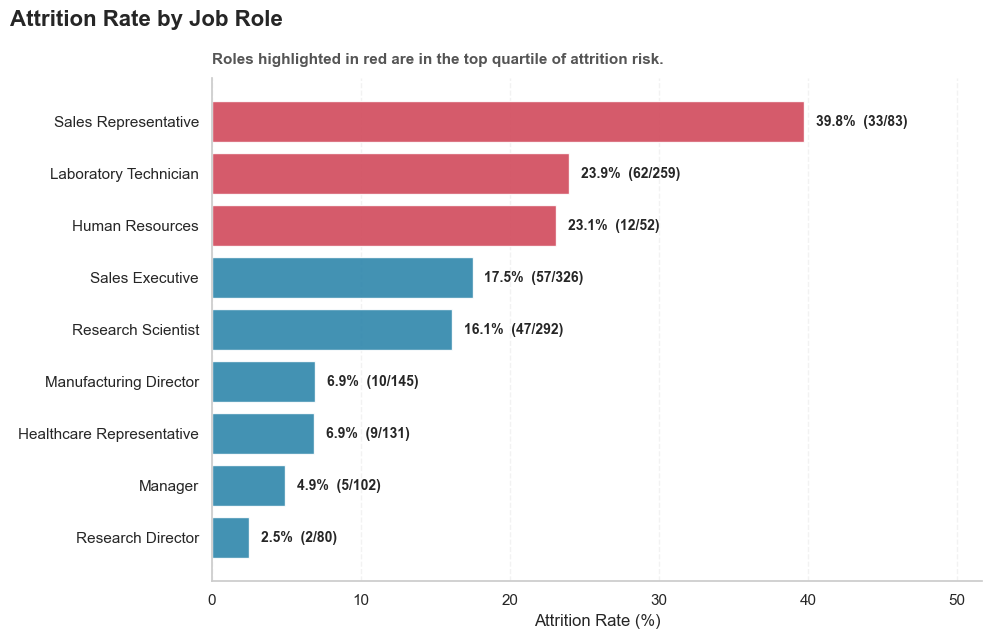

In [25]:

# Step 15: Attrition rate by Job Role


# Calculate job-role-level summary
jobrole_summary = (
    df_clean
    .groupby("JobRole")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
jobrole_summary["attrition_rate_percent"] = jobrole_summary["attrition_rate"] * 100

# Sort by attrition rate
jobrole_summary = jobrole_summary.sort_values(
    "attrition_rate_percent",
    ascending=True
).reset_index(drop=True)

display(jobrole_summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6.5))

# Color highest-risk roles differently
colors = [
    "#D1495B" if rate >= jobrole_summary["attrition_rate_percent"].quantile(0.75)
    else "#2E86AB"
    for rate in jobrole_summary["attrition_rate_percent"]
]

bars = ax.barh(
    jobrole_summary["JobRole"],
    jobrole_summary["attrition_rate_percent"],
    color=colors,
    alpha=0.90
)

# Add labels
for bar, rate, left_count, total_count in zip(
    bars,
    jobrole_summary["attrition_rate_percent"],
    jobrole_summary["employees_left"],
    jobrole_summary["employees"]
):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  ({int(left_count)}/{int(total_count)})",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Job Role",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Roles highlighted in red are in the top quartile of attrition risk.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=10
)

# Formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, jobrole_summary["attrition_rate_percent"].max() * 1.30)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>💼 Conclusion: Attrition Rate by Job Role</h2>

<p>Attrition risk differs strongly across job roles.</p>

<p>The highest-risk role is <strong>Sales Representative</strong>.</p>

</div>

---

## 📊 Job Role Attrition Summary

| Job Role              | Employees Who Left | Total Employees | Attrition Rate |
| --------------------- | -----------------: | --------------: | -------------: |
| Sales Representative  |             **33** |          **83** |      **39.8%** |
| Laboratory Technician |                  — |               — |      **23.9%** |
| Human Resources       |                  — |               — |      **23.1%** |
| Overall Company       |            **237** |       **1,470** |     **16.12%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Highest-Risk Job Role</h3>

<p><strong>Sales Representative</strong> has the highest attrition rate at <strong>39.8%</strong>.</p>

<p>In this role, <strong>33 out of 83 employees</strong> left the company.</p>

<p>This is much higher than the overall company attrition rate of <strong>16.12%</strong>.</p>

</div>

---

## ⚠️ Other High-Risk Roles

Other roles with high attrition rates include:

* **Laboratory Technician**: **23.9%**
* **Human Resources**: **23.1%**

These roles also show attrition rates above the overall company average.

---

## 🧠 Business Interpretation

This suggests that **job role is an important factor** for understanding employee attrition.

Some roles may have higher attrition because of:

* Higher workload
* More pressure
* Limited growth opportunities
* Compensation-related issues
* Lower job satisfaction
* Higher overtime exposure

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Interpretation Note</h3>

<p>Job role appears to be strongly associated with attrition risk.</p>

<p>However, role-level attrition should be combined with other variables before making business decisions.</p>

</div>

---

## 🔗 Variables to Combine Later

This finding should later be analyzed together with:

* **Overtime**
* **Monthly income**
* **Department**
* **Job satisfaction**
* **Work-life balance**
* **Years at company**

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p><strong>Sales Representative</strong> has only <strong>83 employees</strong>.</p>

<p>Therefore, the percentage is high, but the group is smaller than roles such as <strong>Sales Executive</strong> or <strong>Research Scientist</strong>.</p>

<p>This result should be interpreted carefully and not treated as proof that job role alone causes attrition.</p>

</div>

---

## ✅ Final Takeaway

`JobRole` is an important variable for understanding employee attrition.

The **Sales Representative** role should be reviewed closely because it shows the highest attrition rate, but the result should be interpreted together with employee count and other influencing factors.


,Attrition Status,employees,mean,median,q1,q3,minimum,maximum
0,Stayed,1233,6832.740,5204.000,3211.000,8834.000,1051,19999
1,Left,237,4787.093,3202.000,2373.000,5916.000,1009,19859


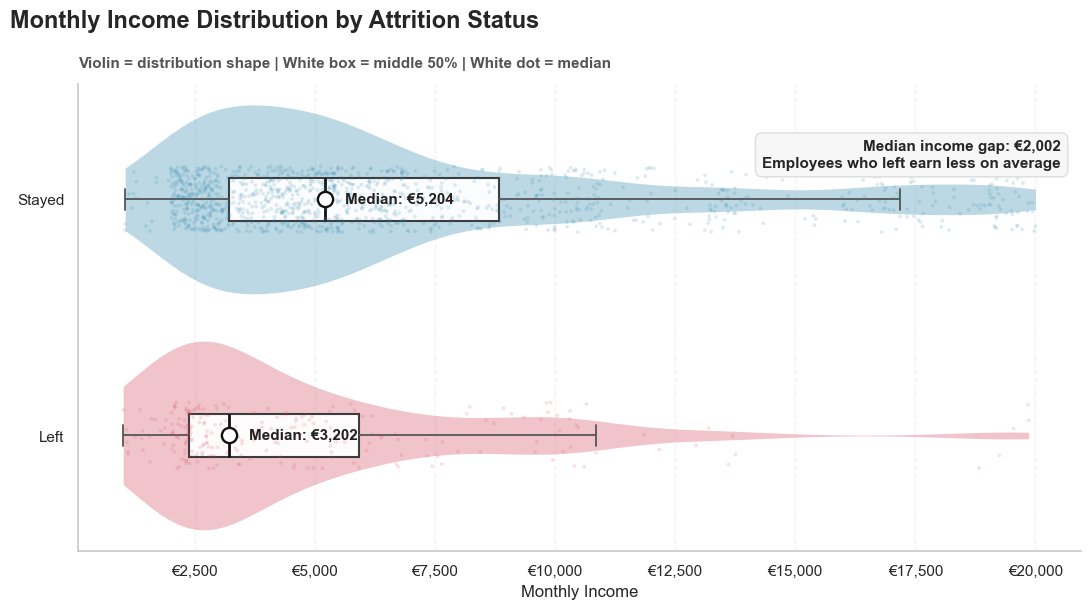

In [29]:

# Step 16: Monthly Income by Attrition Status
# version: Violin + Box + Median


from matplotlib.ticker import FuncFormatter

# Create readable labels
income_plot_data = df_clean.copy()
income_plot_data["Attrition Status"] = income_plot_data["Attrition"].map({
    0: "Stayed",
    1: "Left"
})

order = ["Stayed", "Left"]

# Summary table
income_summary = (
    income_plot_data
    .groupby("Attrition Status")["MonthlyIncome"]
    .agg(
        employees="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        minimum="min",
        maximum="max"
    )
    .reindex(order)
    .reset_index()
)

display(income_summary)

# Key numbers
median_stayed = income_summary.loc[
    income_summary["Attrition Status"] == "Stayed", "median"
].iloc[0]

median_left = income_summary.loc[
    income_summary["Attrition Status"] == "Left", "median"
].iloc[0]

median_gap = median_stayed - median_left

# Colors
palette = {
    "Stayed": "#2E86AB",
    "Left": "#D1495B"
}

# Figure
fig, ax = plt.subplots(figsize=(11, 6.2))

# 1) Violin plot = full distribution shape
sns.violinplot(
    data=income_plot_data,
    y="Attrition Status",
    x="MonthlyIncome",
    order=order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=0,
    saturation=1,
    ax=ax
)

# Make violin slightly transparent
for collection in ax.collections:
    try:
        collection.set_alpha(0.32)
    except:
        pass

# 2) Boxplot = middle 50% of employees
sns.boxplot(
    data=income_plot_data,
    y="Attrition Status",
    x="MonthlyIncome",
    order=order,
    width=0.18,
    showfliers=False,
    boxprops={
        "facecolor": "white",
        "edgecolor": "#333333",
        "linewidth": 1.5,
        "alpha": 0.95
    },
    medianprops={
        "color": "#111111",
        "linewidth": 2
    },
    whiskerprops={
        "color": "#555555",
        "linewidth": 1.3
    },
    capprops={
        "color": "#555555",
        "linewidth": 1.3
    },
    ax=ax
)

# 3) Small dots = individual employees
sns.stripplot(
    data=income_plot_data,
    y="Attrition Status",
    x="MonthlyIncome",
    order=order,
    hue="Attrition Status",
    palette=palette,
    dodge=False,
    jitter=0.14,
    size=2.7,
    alpha=0.16,
    linewidth=0,
    ax=ax
)

# Remove extra legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

# 4) Highlight median with white dot + label
for i, row in income_summary.iterrows():
    ax.scatter(
        row["median"],
        i,
        s=120,
        color="white",
        edgecolor="#111111",
        linewidth=1.7,
        zorder=6
    )
    
    ax.text(
        row["median"] + 420,
        i,
        f"Median: €{row['median']:,.0f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#222222"
    )

# Main insight box
ax.text(
    0.98,
    0.88,
    f"Median income gap: €{median_gap:,.0f}\nEmployees who left earn less on average",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="#F7F7F7",
        edgecolor="#DDDDDD"
    )
)

# Titles
fig.suptitle(
    "Monthly Income Distribution by Attrition Status",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Violin = distribution shape | White box = middle 50% | White dot = median",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Monthly Income")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"€{x:,.0f}"))

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.22)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #22c55e; border-radius:8px;">

<h2>💰 Conclusion: Monthly Income by Attrition Status</h2>

<p>Employees who left the company generally had <strong>lower monthly income</strong> than employees who stayed.</p>

</div>

---

## 📊 Median Monthly Income Summary

| Attrition Status  | Median Monthly Income |
| ----------------- | --------------------: |
| Stayed            |            **€5,204** |
| Left              |            **€3,202** |
| Median income gap |            **€2,002** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Key Income Gap Insight</h3>

<p>The median monthly income for employees who stayed is <strong>€5,204</strong>.</p>

<p>The median monthly income for employees who left is <strong>€3,202</strong>.</p>

<p>This creates a median income gap of approximately <strong>€2,002</strong>.</p>

</div>

---

## 🎻 Distribution Interpretation

The violin plot shows that employees who stayed have a **wider income distribution** and include more higher-income employees.

Employees who left are more concentrated in the **lower-income range**.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Important Pattern</h3>

<p>Employees who left are more concentrated in lower monthly income ranges.</p>

<p>This suggests that <code>MonthlyIncome</code> may be an important variable for predicting employee attrition.</p>

</div>

---

## 🧠 Business Interpretation

This finding suggests that monthly income may be associated with employee attrition.

Employees with lower income may have:

* Lower financial satisfaction
* Fewer perceived rewards
* Higher sensitivity to external job offers
* Lower attachment to the company
* Fewer career progression signals

---

## ⚠️ Important Caution

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<p>This should be interpreted as an <strong>association</strong>, not proof that income alone causes employees to leave.</p>

<p>Other factors may also influence attrition, such as:</p>

<ul>
<li>Job role</li>
<li>Job level</li>
<li>Overtime</li>
<li>Department</li>
<li>Job satisfaction</li>
<li>Career growth</li>
</ul>

</div>

---

## ✅ Final Takeaway

`MonthlyIncome` appears to be an important variable for understanding employee attrition.

Employees who left had a noticeably lower median monthly income, but this finding should be interpreted together with role, level, satisfaction, overtime, and career growth factors.


,AgeBand,employees,employees_left,attrition_rate,attrition_rate_percent
0,18–25,123,44,0.358,35.772
1,26–30,263,56,0.213,21.293
2,31–35,343,60,0.175,17.493
3,36–40,276,25,0.091,9.058
4,41–45,192,18,0.094,9.375
5,46–50,130,16,0.123,12.308
6,51–60,143,18,0.126,12.587


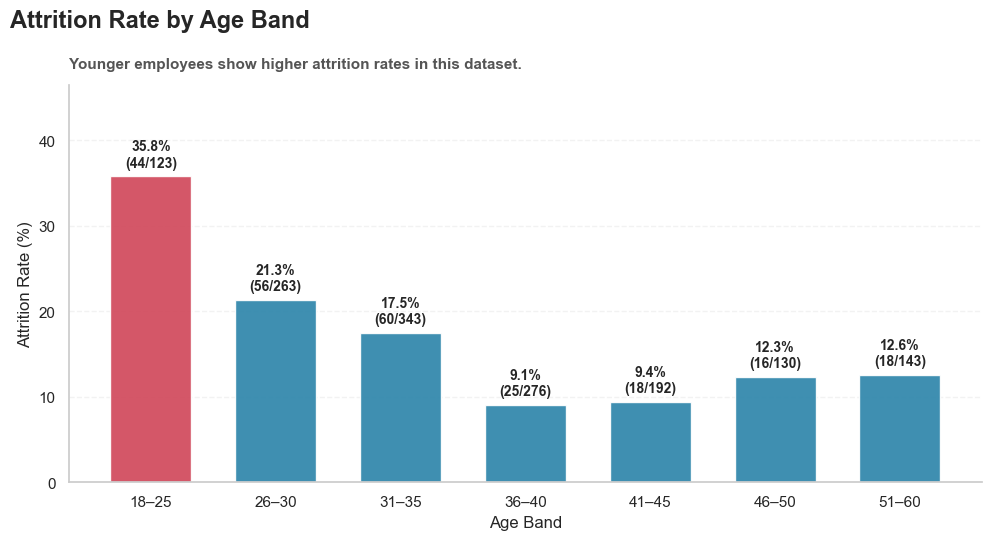

In [30]:
# Step 17: Attrition rate by Age Band


# Create a working copy for age analysis
age_band_data = df_clean.copy()

# Create age bands
age_bins = [17, 25, 30, 35, 40, 45, 50, 60]
age_labels = ["18–25", "26–30", "31–35", "36–40", "41–45", "46–50", "51–60"]

age_band_data["AgeBand"] = pd.cut(
    age_band_data["Age"],
    bins=age_bins,
    labels=age_labels
)

# Calculate attrition summary by age band
age_band_summary = (
    age_band_data
    .groupby("AgeBand", observed=True)
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert to percentage
age_band_summary["attrition_rate_percent"] = age_band_summary["attrition_rate"] * 100

display(age_band_summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Color highest attrition band differently
max_rate = age_band_summary["attrition_rate_percent"].max()

colors = [
    "#D1495B" if rate == max_rate else "#2E86AB"
    for rate in age_band_summary["attrition_rate_percent"]
]

# Bar chart
bars = ax.bar(
    age_band_summary["AgeBand"].astype(str),
    age_band_summary["attrition_rate_percent"],
    color=colors,
    width=0.65,
    alpha=0.92
)

# Add labels above bars
for bar, rate, left_count, total_count in zip(
    bars,
    age_band_summary["attrition_rate_percent"],
    age_band_summary["employees_left"],
    age_band_summary["employees"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{rate:.1f}%\n({int(left_count)}/{int(total_count)})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Age Band",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Younger employees show higher attrition rates in this dataset.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Age Band")
ax.set_ylabel("Attrition Rate (%)")

ax.set_ylim(0, age_band_summary["attrition_rate_percent"].max() * 1.30)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>🎂 Conclusion: Attrition Rate by Age Band</h2>

<p>The age-band analysis shows that <strong>younger employees have higher attrition rates</strong>.</p>

</div>

---

## 📊 Attrition Summary by Age Band

| Age Band | Employees Who Left | Total Employees |  Attrition Rate |
| -------- | -----------------: | --------------: | --------------: |
| 18–25    |             **44** |         **123** |       **35.8%** |
| 26–30    |                  — |               — |       **21.3%** |
| 31–35    |                  — |               — |       **17.5%** |
| Above 35 |                  — |               — | Lower attrition |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Highest-Risk Age Group</h3>

<p>The highest attrition rate is in the <strong>18–25</strong> age group.</p>

<p>In this group, <strong>44 out of 123 employees</strong> left the company.</p>

<p>This gives an attrition rate of <strong>35.8%</strong>.</p>

</div>

---

## 📉 Age-Related Attrition Pattern

The attrition rate decreases in the older age bands:

* Employees aged **26–30** have an attrition rate of **21.3%**
* Employees aged **31–35** have an attrition rate of **17.5%**
* After age **35**, the attrition rate is much lower

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Key Pattern</h3>

<p>Attrition risk is highest among the youngest employees and becomes lower after age 35.</p>

<p>This suggests that <code>Age</code> may be an important variable for predicting employee attrition.</p>

</div>

---

## 🧠 Business Interpretation

Younger employees may be more likely to leave because they may:

* Explore new career opportunities
* Change roles more frequently
* Compare salary and growth options externally
* Have different expectations around work-life balance
* Leave if career development expectations are not met

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>This should be interpreted as an <strong>association</strong>, not direct proof that age alone causes attrition.</p>

<p>Other factors such as salary, job role, overtime, career growth, satisfaction, and work-life balance may also influence attrition.</p>

</div>

---

## ✅ Final Takeaway

`Age` appears to be an important attrition-related variable.

Younger employees, especially those aged **18–25**, should be reviewed carefully for possible issues related to onboarding, salary expectations, career growth, and work-life balance.


,YearsAtCompanyBand,employees,employees_left,attrition_rate,attrition_rate_percent
0,0–1,215,75,0.349,34.884
1,2–3,255,47,0.184,18.431
2,4–5,306,40,0.131,13.072
3,6–10,448,55,0.123,12.277
4,11–20,180,12,0.067,6.667
5,21+,66,8,0.121,12.121


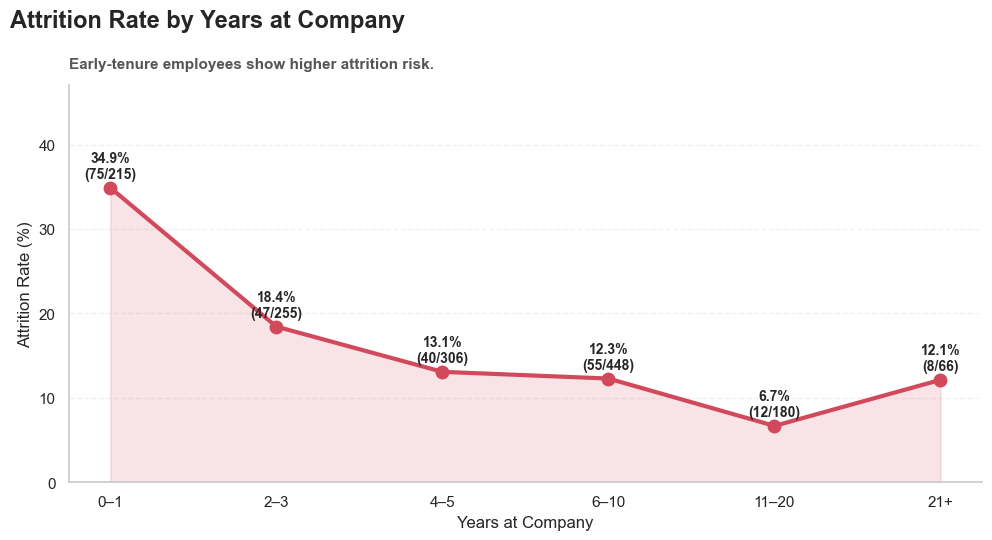

In [31]:
# Step 18: Attrition rate by Years at Company band


# Create a working copy
tenure_data = df_clean.copy()

# Create tenure bands
tenure_bins = [-1, 1, 3, 5, 10, 20, 40]
tenure_labels = ["0–1", "2–3", "4–5", "6–10", "11–20", "21+"]

tenure_data["YearsAtCompanyBand"] = pd.cut(
    tenure_data["YearsAtCompany"],
    bins=tenure_bins,
    labels=tenure_labels
)

# Calculate attrition summary by tenure band
tenure_summary = (
    tenure_data
    .groupby("YearsAtCompanyBand", observed=True)
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
tenure_summary["attrition_rate_percent"] = tenure_summary["attrition_rate"] * 100

display(tenure_summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Line chart
ax.plot(
    tenure_summary["YearsAtCompanyBand"].astype(str),
    tenure_summary["attrition_rate_percent"],
    color="#D1495B",
    marker="o",
    linewidth=3,
    markersize=9
)

# Fill area under line
ax.fill_between(
    tenure_summary["YearsAtCompanyBand"].astype(str),
    tenure_summary["attrition_rate_percent"],
    color="#D1495B",
    alpha=0.15
)

# Add labels for each point
for x, rate, left_count, total_count in zip(
    tenure_summary["YearsAtCompanyBand"].astype(str),
    tenure_summary["attrition_rate_percent"],
    tenure_summary["employees_left"],
    tenure_summary["employees"]
):
    ax.text(
        x,
        rate + 0.8,
        f"{rate:.1f}%\n({int(left_count)}/{int(total_count)})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Years at Company",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Early-tenure employees show higher attrition risk.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Years at Company")
ax.set_ylabel("Attrition Rate (%)")

ax.set_ylim(0, tenure_summary["attrition_rate_percent"].max() * 1.35)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>⏳ Conclusion: Attrition Rate by Years at Company</h2>

<p>Employees with <strong>shorter tenure</strong> show a much higher attrition rate.</p>

<p>This suggests that early-tenure employees are at greater risk of leaving.</p>

</div>

---

## 📊 Attrition Summary by Years at Company

| Years at Company | Employees Who Left | Total Employees | Attrition Rate |
| ---------------- | -----------------: | --------------: | -------------: |
| 0–1 years        |             **75** |         **215** |      **34.9%** |
| 2–3 years        |                  — |               — |      **18.4%** |
| 4–5 years        |                  — |               — |      **13.1%** |
| 21+ years        |                  — |          **66** |      **12.1%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Highest-Risk Tenure Group</h3>

<p>The highest attrition rate is in the <strong>0–1 years</strong> group.</p>

<p>In this group, <strong>75 out of 215 employees</strong> left the company.</p>

<p>This gives an attrition rate of <strong>34.9%</strong>.</p>

</div>

---

## 📉 Tenure-Related Attrition Pattern

After the first few years, attrition decreases clearly.

* Employees with **2–3 years** at the company have an attrition rate of **18.4%**
* Employees with **4–5 years** at the company have an attrition rate of **13.1%**

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Key Pattern</h3>

<p>Attrition risk is highest during the first year of employment.</p>

<p>After employees stay beyond the early-tenure period, the likelihood of leaving decreases clearly.</p>

</div>

---

## 🧠 Business Interpretation

This suggests that early-tenure employees are at higher risk of leaving.

Possible reasons could include:

* Weak onboarding experience
* Mismatch between job expectations and reality
* Early career exploration
* Limited perceived growth opportunities
* Lack of connection with the company
* Poor early manager support

---

## ⚠️ Important Caution

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<p>The <strong>21+ years</strong> group shows a slight increase in attrition rate to <strong>12.1%</strong>.</p>

<p>However, this group is small, with only <strong>66 employees</strong>.</p>

<p>Therefore, this percentage should be interpreted carefully and not overgeneralized.</p>

</div>

---

## ✅ Final Takeaway

`YearsAtCompany` appears to be an important variable for understanding and predicting employee attrition.

The biggest business focus should be on employees in their **first year**, because this group shows the highest attrition risk.


,JobSatisfaction,employees,employees_left,attrition_rate,attrition_rate_percent
0,1,289,66,0.228,22.837
1,2,280,46,0.164,16.429
2,3,442,73,0.165,16.516
3,4,459,52,0.113,11.329


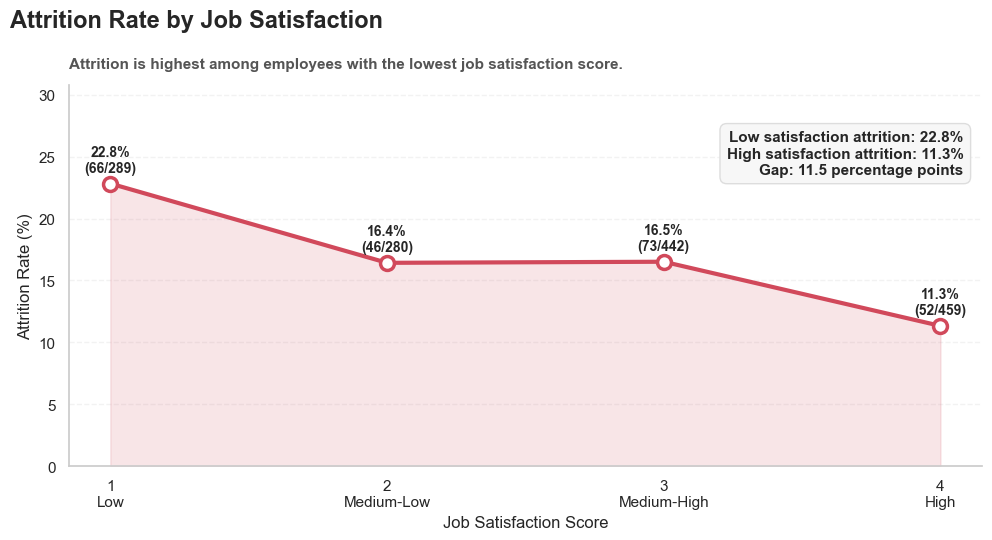

In [33]:
# Step 19: Attrition rate by Job Satisfaction



# Create summary by JobSatisfaction score
satisfaction_summary = (
    df_clean
    .groupby("JobSatisfaction")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
satisfaction_summary["attrition_rate_percent"] = satisfaction_summary["attrition_rate"] * 100

display(satisfaction_summary)

# Create readable labels for x-axis
satisfaction_labels = {
    1: "1\nLow",
    2: "2\nMedium-Low",
    3: "3\nMedium-High",
    4: "4\nHigh"
}

satisfaction_summary["label"] = satisfaction_summary["JobSatisfaction"].map(satisfaction_labels)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft area under line
ax.fill_between(
    satisfaction_summary["JobSatisfaction"],
    satisfaction_summary["attrition_rate_percent"],
    color="#D1495B",
    alpha=0.14
)

# Trend line
ax.plot(
    satisfaction_summary["JobSatisfaction"],
    satisfaction_summary["attrition_rate_percent"],
    color="#D1495B",
    linewidth=3,
    marker="o",
    markersize=10,
    markerfacecolor="white",
    markeredgecolor="#D1495B",
    markeredgewidth=2.5
)

# Add labels for each point
for _, row in satisfaction_summary.iterrows():
    ax.text(
        row["JobSatisfaction"],
        row["attrition_rate_percent"] + 0.7,
        f"{row['attrition_rate_percent']:.1f}%\n({int(row['employees_left'])}/{int(row['employees'])})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Highlight lowest and highest satisfaction
lowest_rate = satisfaction_summary.loc[
    satisfaction_summary["JobSatisfaction"] == 1,
    "attrition_rate_percent"
].iloc[0]

highest_rate = satisfaction_summary.loc[
    satisfaction_summary["JobSatisfaction"] == 4,
    "attrition_rate_percent"
].iloc[0]

gap = lowest_rate - highest_rate

# Insight box
ax.text(
    0.98,
    0.88,
    f"Low satisfaction attrition: {lowest_rate:.1f}%\n"
    f"High satisfaction attrition: {highest_rate:.1f}%\n"
    f"Gap: {gap:.1f} percentage points",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="#F7F7F7",
        edgecolor="#DDDDDD"
    )
)

# Titles
fig.suptitle(
    "Attrition Rate by Job Satisfaction",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Attrition is highest among employees with the lowest job satisfaction score.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Job Satisfaction Score")
ax.set_ylabel("Attrition Rate (%)")

ax.set_xticks(satisfaction_summary["JobSatisfaction"])
ax.set_xticklabels(satisfaction_summary["label"])

ax.set_ylim(0, satisfaction_summary["attrition_rate_percent"].max() * 1.35)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>😊 Conclusion: Job Satisfaction and Attrition</h2>

<p>Employees with the <strong>lowest job satisfaction score</strong> show the highest attrition rate.</p>

<p>This suggests that job satisfaction is an important attrition-related signal.</p>

</div>

---

## 📊 Attrition Rate by Job Satisfaction

| Job Satisfaction Score |             Attrition Rate |
| ---------------------- | -------------------------: |
| 1 — Low                |                  **22.8%** |
| 4 — High               |                  **11.3%** |
| Difference             | **11.5 percentage points** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>Employees with a job satisfaction score of <strong>1</strong> have an attrition rate of <strong>22.8%</strong>.</p>

<p>Employees with the highest satisfaction score of <strong>4</strong> have an attrition rate of only <strong>11.3%</strong>.</p>

<p>This creates a gap of <strong>11.5 percentage points</strong>.</p>

</div>

---

## 🧠 Business Interpretation

This suggests that **job satisfaction is related to employee attrition**.

Employees who are less satisfied with their job appear more likely to leave the company.

Possible reasons may include:

* Lower motivation
* Poorer employee experience
* Frustration with role expectations
* Weak relationship with manager or team
* Limited growth or recognition

---

## 📌 Pattern Interpretation

The pattern is **not perfectly linear**, because satisfaction scores **2** and **3** have very similar attrition rates.

Therefore, the strongest business takeaway is:

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Main Business Takeaway</h3>

<p><strong>Very low job satisfaction is a warning signal.</strong></p>

<p>High job satisfaction is associated with lower attrition.</p>

</div>

---

## ⚠️ Important Caution

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<p>This should be interpreted as an <strong>association</strong>, not direct proof that job satisfaction alone causes attrition.</p>

<p>Other variables such as overtime, income, job role, department, work-life balance, and career growth may also influence attrition.</p>

</div>

---

## ✅ Final Takeaway

`JobSatisfaction` appears to be an important variable for understanding employee attrition.

The clearest HR signal is that employees with **very low job satisfaction** should be monitored carefully and supported early.


,WorkLifeBalance,employees,employees_left,attrition_rate,attrition_rate_percent,label
0,1,80,25,0.312,31.250,Poor
1,2,344,58,0.169,16.860,Fair
2,3,893,127,0.142,14.222,Good
3,4,153,27,0.176,17.647,Excellent


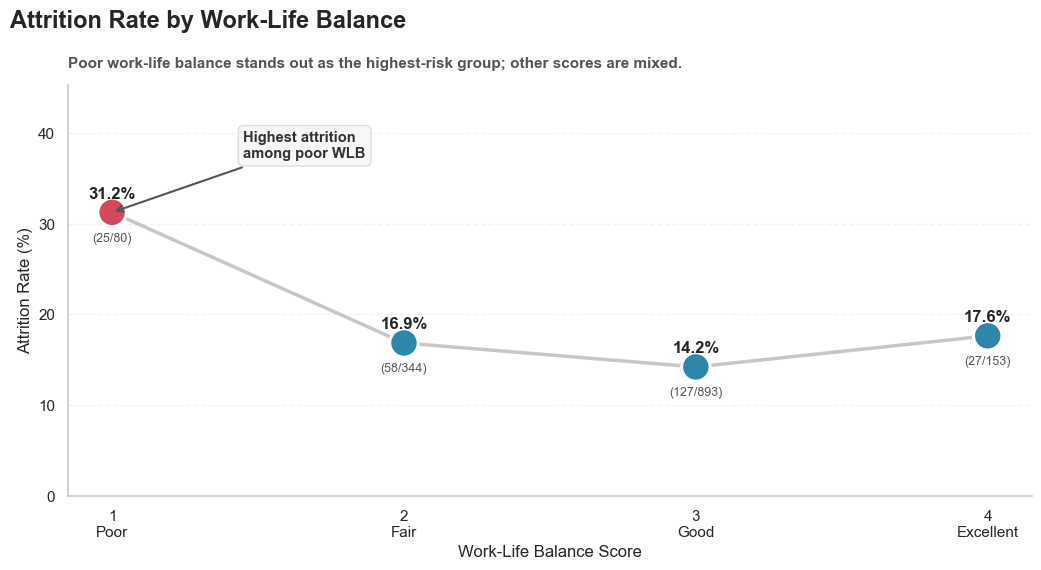

In [35]:
# Step 20: Attrition rate by Work-Life Balance



# Create summary by WorkLifeBalance score
wlb_summary = (
    df_clean
    .groupby("WorkLifeBalance")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert to percentage
wlb_summary["attrition_rate_percent"] = wlb_summary["attrition_rate"] * 100

# Add readable labels
wlb_labels = {
    1: "Poor",
    2: "Fair",
    3: "Good",
    4: "Excellent"
}

wlb_summary["label"] = wlb_summary["WorkLifeBalance"].map(wlb_labels)

# Sort naturally from 1 to 4
wlb_summary = wlb_summary.sort_values("WorkLifeBalance").reset_index(drop=True)

display(wlb_summary)

# Key numbers
poor_rate = wlb_summary.loc[
    wlb_summary["WorkLifeBalance"] == 1,
    "attrition_rate_percent"
].iloc[0]

good_rate = wlb_summary.loc[
    wlb_summary["WorkLifeBalance"] == 3,
    "attrition_rate_percent"
].iloc[0]

excellent_rate = wlb_summary.loc[
    wlb_summary["WorkLifeBalance"] == 4,
    "attrition_rate_percent"
].iloc[0]

# Create figure
fig, ax = plt.subplots(figsize=(10.5, 5.8))

# X and Y
x = wlb_summary["WorkLifeBalance"]
y = wlb_summary["attrition_rate_percent"]

# Soft connecting line
ax.plot(
    x,
    y,
    color="#9A9A9A",
    linewidth=2.5,
    alpha=0.55,
    zorder=1
)

# Points
colors = [
    "#D1495B" if score == 1 else "#2E86AB"
    for score in wlb_summary["WorkLifeBalance"]
]

ax.scatter(
    x,
    y,
    s=420,
    color=colors,
    edgecolor="white",
    linewidth=2.2,
    zorder=3
)

# Add labels near points
for _, row in wlb_summary.iterrows():
    ax.text(
        row["WorkLifeBalance"],
        row["attrition_rate_percent"] + 1.2,
        f"{row['attrition_rate_percent']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )
    
    ax.text(
        row["WorkLifeBalance"],
        row["attrition_rate_percent"] - 2.2,
        f"({int(row['employees_left'])}/{int(row['employees'])})",
        ha="center",
        va="top",
        fontsize=9,
        color="#555555"
    )

# Insight annotation
ax.annotate(
    "Highest attrition\namong poor WLB",
    xy=(1, poor_rate),
    xytext=(1.45, poor_rate + 6),
    arrowprops=dict(
        arrowstyle="->",
        color="#555555",
        lw=1.5
    ),
    fontsize=10.5,
    fontweight="bold",
    color="#333333",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#F7F7F7",
        edgecolor="#DDDDDD"
    )
)

# Title and subtitle
fig.suptitle(
    "Attrition Rate by Work-Life Balance",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Poor work-life balance stands out as the highest-risk group; other scores are mixed.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Work-Life Balance Score")
ax.set_ylabel("Attrition Rate (%)")

ax.set_xticks(wlb_summary["WorkLifeBalance"])
ax.set_xticklabels(
    [
        "1\nPoor",
        "2\nFair",
        "3\nGood",
        "4\nExcellent"
    ]
)

ax.set_ylim(0, max(y) * 1.45)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

## Conclusion: Work-Life Balance and Attrition

Employees with the poorest work-life balance show the highest attrition rate.

Employees with a work-life balance score of **1 - Poor** have an attrition rate of **31.2%**, with **25 out of 80 employees** leaving the company. This is much higher than the overall company attrition rate of **16.12%**.

The other work-life balance groups have lower attrition rates: **16.9%** for **Fair**, **14.2%** for **Good**, and **17.6%** for **Excellent**.

The pattern is not perfectly linear because the **Excellent** group has a slightly higher attrition rate than the **Good** group. Therefore, the main takeaway is that **poor work-life balance is a clear risk signal**, but work-life balance alone does not fully explain attrition.

Other factors such as overtime, job role, income, years at company, job satisfaction, and department may also influence whether an employee leaves.

,EnvironmentSatisfaction,employees,employees_left,attrition_rate,attrition_rate_percent,Environment Satisfaction
0,4,446,60,0.135,13.453,4 - High
1,3,453,62,0.137,13.687,3 - Medium-High
2,2,287,43,0.150,14.983,2 - Medium-Low
3,1,284,72,0.254,25.352,1 - Low


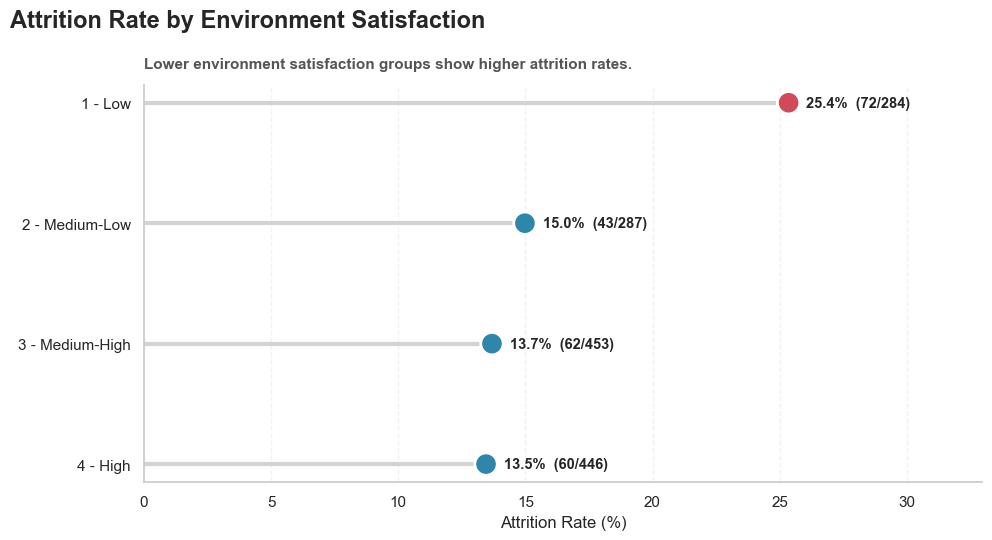

In [36]:
# Step 21: Attrition rate by Environment Satisfaction



# Create summary by EnvironmentSatisfaction score
environment_summary = (
    df_clean
    .groupby("EnvironmentSatisfaction")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
environment_summary["attrition_rate_percent"] = environment_summary["attrition_rate"] * 100

# Add readable labels
environment_labels = {
    1: "1 - Low",
    2: "2 - Medium-Low",
    3: "3 - Medium-High",
    4: "4 - High"
}

environment_summary["Environment Satisfaction"] = (
    environment_summary["EnvironmentSatisfaction"].map(environment_labels)
)

# Sort by attrition rate for ranking
environment_summary = environment_summary.sort_values(
    "attrition_rate_percent",
    ascending=True
).reset_index(drop=True)

display(environment_summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Draw horizontal guide lines
ax.hlines(
    y=environment_summary["Environment Satisfaction"],
    xmin=0,
    xmax=environment_summary["attrition_rate_percent"],
    color="#C9C9C9",
    linewidth=3,
    alpha=0.8
)

# Highlight highest attrition group
max_rate = environment_summary["attrition_rate_percent"].max()

colors = [
    "#D1495B" if rate == max_rate else "#2E86AB"
    for rate in environment_summary["attrition_rate_percent"]
]

# Dots
ax.scatter(
    environment_summary["attrition_rate_percent"],
    environment_summary["Environment Satisfaction"],
    s=260,
    color=colors,
    edgecolor="white",
    linewidth=2,
    zorder=3
)

# Labels beside dots
for _, row in environment_summary.iterrows():
    ax.text(
        row["attrition_rate_percent"] + 0.7,
        row["Environment Satisfaction"],
        f"{row['attrition_rate_percent']:.1f}%  ({int(row['employees_left'])}/{int(row['employees'])})",
        va="center",
        fontsize=10.5,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Environment Satisfaction",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Lower environment satisfaction groups show higher attrition rates.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, environment_summary["attrition_rate_percent"].max() * 1.30)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #22c55e; border-radius:8px;">

<h2>🌱 Conclusion: Environment Satisfaction and Attrition</h2>

<p>Employees with <strong>low environment satisfaction</strong> show the highest attrition rate.</p>

<p>This suggests that the work environment is an important attrition-related signal.</p>

</div>

---

## 📊 Attrition Rate by Environment Satisfaction

| Environment Satisfaction Score | Interpretation | Employees Who Left | Total Employees | Attrition Rate |
| ------------------------------ | -------------- | -----------------: | --------------: | -------------: |
| 1                              | Low            |             **72** |         **284** |      **25.4%** |
| 2                              | Medium-Low     |                  — |               — |      **15.0%** |
| 3                              | Medium-High    |                  — |               — |      **13.7%** |
| 4                              | High           |                  — |               — |      **13.5%** |
| Overall Company                | —              |            **237** |       **1,470** |     **16.12%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>Employees with an environment satisfaction score of <strong>1 - Low</strong> have an attrition rate of <strong>25.4%</strong>.</p>

<p>In this group, <strong>72 out of 284 employees</strong> left the company.</p>

<p>This is much higher than the overall company attrition rate of <strong>16.12%</strong>.</p>

</div>

---

## 📉 Satisfaction Pattern

The attrition rate decreases for higher environment satisfaction scores:

* **15.0%** for Medium-Low
* **13.7%** for Medium-High
* **13.5%** for High

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Main Pattern</h3>

<p>The biggest attrition risk appears in the lowest environment satisfaction group.</p>

<p>After satisfaction improves above the lowest level, attrition becomes much closer to the company average.</p>

</div>

---

## 🧠 Business Interpretation

This suggests that **environment satisfaction may be an important variable** for understanding employee attrition.

Employees who are less satisfied with their work environment may be more likely to leave because of:

* Poor workplace conditions
* Team or manager-related issues
* Low psychological comfort
* Lack of support
* Poor communication or culture
* Higher day-to-day work friction

---

## ⚠️ Important Caution

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<p>This should be interpreted as an <strong>association</strong>, not direct proof that environment satisfaction alone causes attrition.</p>

<p>Other factors may also influence employee attrition, such as:</p>

<ul>
<li>Overtime</li>
<li>Job role</li>
<li>Monthly income</li>
<li>Job satisfaction</li>
<li>Work-life balance</li>
<li>Years at company</li>
</ul>

</div>

---

## ✅ Final Takeaway

`EnvironmentSatisfaction` appears to be an important attrition-related variable.

The strongest warning signal is **low environment satisfaction**, especially score **1**, where attrition is clearly higher than the overall company average.


,feature,segment,employees,employees_left,attrition_rate_percent,lift_vs_average
0,Department,Sales,446,92,20.628,1.279
1,AgeBand,26–30,263,56,21.293,1.321
2,JobSatisfactionLabel,Low,289,66,22.837,1.416
3,JobRole,Human Resources,52,12,23.077,1.431
4,JobRole,Laboratory Technician,259,62,23.938,1.485
5,BusinessTravel,Travel_Frequently,277,69,24.910,1.545
6,EnvironmentSatisfactionLabel,Low,284,72,25.352,1.572
7,OverTime,Yes,416,127,30.529,1.894
8,WorkLifeBalanceLabel,Poor,80,25,31.250,1.938
9,YearsAtCompanyBand,0–1,215,75,34.884,2.164


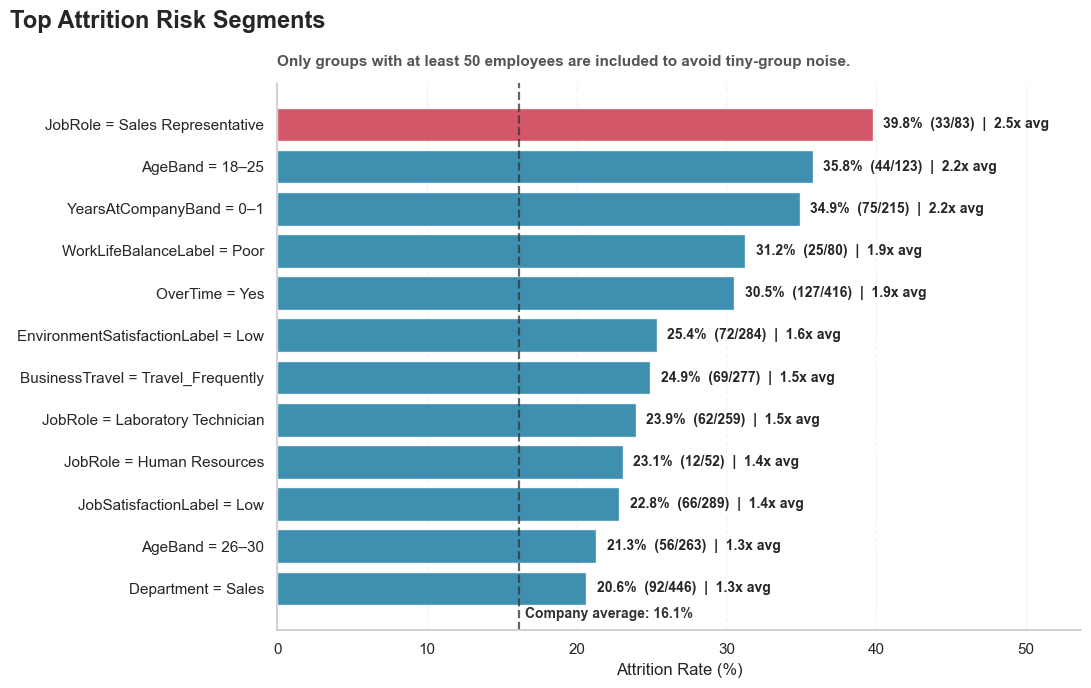

In [37]:
# Step 22: Final EDA summary — Top attrition risk segments


# Overall company attrition rate
overall_attrition_rate = df_clean["Attrition"].mean() * 100

# Create a working copy
risk_data = df_clean.copy()

# Create age bands again
age_bins = [17, 25, 30, 35, 40, 45, 50, 60]
age_labels = ["18–25", "26–30", "31–35", "36–40", "41–45", "46–50", "51–60"]

risk_data["AgeBand"] = pd.cut(
    risk_data["Age"],
    bins=age_bins,
    labels=age_labels
)

# Create years-at-company bands again
tenure_bins = [-1, 1, 3, 5, 10, 20, 40]
tenure_labels = ["0–1", "2–3", "4–5", "6–10", "11–20", "21+"]

risk_data["YearsAtCompanyBand"] = pd.cut(
    risk_data["YearsAtCompany"],
    bins=tenure_bins,
    labels=tenure_labels
)

# Make score columns easier to understand
risk_data["JobSatisfactionLabel"] = risk_data["JobSatisfaction"].map({
    1: "Low",
    2: "Medium-Low",
    3: "Medium-High",
    4: "High"
})

risk_data["EnvironmentSatisfactionLabel"] = risk_data["EnvironmentSatisfaction"].map({
    1: "Low",
    2: "Medium-Low",
    3: "Medium-High",
    4: "High"
})

risk_data["WorkLifeBalanceLabel"] = risk_data["WorkLifeBalance"].map({
    1: "Poor",
    2: "Fair",
    3: "Good",
    4: "Excellent"
})

# Variables we want to summarize
segment_columns = [
    "OverTime",
    "BusinessTravel",
    "Department",
    "JobRole",
    "AgeBand",
    "YearsAtCompanyBand",
    "JobSatisfactionLabel",
    "EnvironmentSatisfactionLabel",
    "WorkLifeBalanceLabel"
]

# Function to calculate attrition rate for each segment
def summarize_segments(data, column):
    summary = (
        data
        .groupby(column, observed=True)
        .agg(
            employees=("Attrition", "size"),
            employees_left=("Attrition", "sum"),
            attrition_rate=("Attrition", "mean")
        )
        .reset_index()
    )
    
    summary["feature"] = column
    summary["segment"] = summary[column].astype(str)
    summary["attrition_rate_percent"] = summary["attrition_rate"] * 100
    summary["lift_vs_average"] = summary["attrition_rate_percent"] / overall_attrition_rate
    
    return summary[[
        "feature",
        "segment",
        "employees",
        "employees_left",
        "attrition_rate_percent",
        "lift_vs_average"
    ]]

# Combine all segment summaries
all_segments = pd.concat(
    [summarize_segments(risk_data, column) for column in segment_columns],
    ignore_index=True
)

# Keep only reasonably sized groups
# This avoids misleading conclusions from tiny groups.
minimum_group_size = 50

top_risk_segments = (
    all_segments
    .query("employees >= @minimum_group_size")
    .sort_values("attrition_rate_percent", ascending=False)
    .head(12)
    .sort_values("attrition_rate_percent", ascending=True)
    .reset_index(drop=True)
)

display(top_risk_segments)

# Create readable label for chart
top_risk_segments["chart_label"] = (
    top_risk_segments["feature"]
    + " = "
    + top_risk_segments["segment"]
)

# Create figure
fig, ax = plt.subplots(figsize=(11, 7))

# Color highest risk group differently
max_rate = top_risk_segments["attrition_rate_percent"].max()

colors = [
    "#D1495B" if rate == max_rate else "#2E86AB"
    for rate in top_risk_segments["attrition_rate_percent"]
]

bars = ax.barh(
    top_risk_segments["chart_label"],
    top_risk_segments["attrition_rate_percent"],
    color=colors,
    alpha=0.92
)

# Add value labels
for bar, rate, left_count, total_count, lift in zip(
    bars,
    top_risk_segments["attrition_rate_percent"],
    top_risk_segments["employees_left"],
    top_risk_segments["employees"],
    top_risk_segments["lift_vs_average"]
):
    ax.text(
        bar.get_width() + 0.7,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  ({int(left_count)}/{int(total_count)})  |  {lift:.1f}x avg",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Overall average line
ax.axvline(
    overall_attrition_rate,
    color="#333333",
    linestyle="--",
    linewidth=1.6,
    alpha=0.75
)

ax.text(
    overall_attrition_rate + 0.4,
    -0.7,
    f"Company average: {overall_attrition_rate:.1f}%",
    fontsize=10,
    color="#333333",
    fontweight="bold"
)

# Titles
fig.suptitle(
    "Top Attrition Risk Segments",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    f"Only groups with at least {minimum_group_size} employees are included to avoid tiny-group noise.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, top_risk_segments["attrition_rate_percent"].max() * 1.35)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #ef4444; border-radius:8px;">

<h2>🚨 Conclusion: Top Attrition Risk Segments</h2>

<p>The final EDA summary highlights the employee groups with the <strong>highest attrition rates</strong>.</p>

<p>Only groups with at least <strong>50 employees</strong> were included to avoid misleading conclusions from very small sample sizes.</p>

</div>

---

## 📊 High-Risk Attrition Segments

The overall company attrition rate is **16.1%**.

Several employee groups show much higher attrition rates than this average.

| Risk Segment            | Attrition Rate | Business Meaning             |
| ----------------------- | -------------: | ---------------------------- |
| Sales Representatives   |      **39.8%** | Highest-risk job role        |
| Age 18–25               |      **35.8%** | Highest-risk age group       |
| 0–1 years at company    |      **34.9%** | Highest-risk tenure group    |
| Poor work-life balance  |      **31.2%** | Strong work-life risk signal |
| Overtime employees      |      **30.5%** | High workload risk signal    |
| Overall company average |      **16.1%** | Baseline comparison          |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Highest-Risk Group</h3>

<p>The highest-risk group is <strong>Sales Representatives</strong>, with an attrition rate of <strong>39.8%</strong>.</p>

<p>This is about <strong>2.5 times higher</strong> than the overall company average of <strong>16.1%</strong>.</p>

</div>

---

## 🔍 Main Risk Concentration

The analysis shows that attrition risk is **not random**.

It appears to be concentrated among specific employee groups, especially:

* Early-career employees
* Early-tenure employees
* Sales Representatives
* Employees working overtime
* Employees with poor work-life balance
* Employees with low satisfaction scores

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Business Risk Insight</h3>

<p>Several employee groups have attrition rates close to or above <strong>30%</strong>.</p>

<p>These groups should be prioritized for deeper HR analysis and retention planning.</p>

</div>

---

## 🧠 Business Interpretation

These findings suggest that attrition is concentrated around a few important themes:

| Theme                  | Possible Business Interpretation                          |
| ---------------------- | --------------------------------------------------------- |
| Early career risk      | Younger employees may explore alternatives more often     |
| Early tenure risk      | Onboarding or expectation mismatch may affect retention   |
| Role-based risk        | Some roles may face higher pressure or lower satisfaction |
| Workload risk          | Overtime may increase stress and burnout risk             |
| Work-life balance risk | Poor balance may increase likelihood of leaving           |

---

## ⚠️ Important Caution

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<p>These findings are useful for business understanding, but they should be treated as <strong>associations</strong>, not direct proof of cause.</p>

<p>Other variables may also influence attrition, such as income, department, satisfaction, job level, manager support, and career growth.</p>

</div>

---

## ✅ Transition to Machine Learning

In the next section, we move from **exploratory data analysis** to **machine learning preprocessing**.

The goal is to prepare these variables properly for model training so the model can learn patterns related to employee attrition.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #22c55e; border-radius:8px;">

<h3>✅ Final Takeaway</h3>

<p>Attrition risk is clearly concentrated in specific employee segments.</p>

<p>The most important segments to monitor are <strong>Sales Representatives, younger employees, early-tenure employees, overtime employees, and employees with poor work-life balance or low satisfaction</strong>.</p>

</div>


In [38]:
# Step 23: Separate features X and target y


# X contains all input features except the target column
X = df_clean.drop(columns=["Attrition"])

# y contains only the target column
y = df_clean["Attrition"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nTarget distribution:")
display(y.value_counts().rename(index={0: "Stayed", 1: "Left"}))

print("\nFirst 5 rows of X:")
display(X.head())

Shape of X: (1470, 30)
Shape of y: (1470,)

Target distribution:


Attrition
Stayed    1233
Left       237
Name: count, dtype: int64


First 5 rows of X:


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


## Conclusion: Feature and Target Split

The cleaned dataset was split into input features and the target variable.

`X` contains the employee information used for prediction, such as age, job role, monthly income, overtime status, satisfaction scores, and years at company.

`y` contains the target variable, `Attrition`, which tells us whether an employee stayed or left the company.

After the split, `X` has **1470 rows and 30 input features**, while `y` has **1470 target values**.

This step prepares the dataset for machine learning, where the model will learn patterns from `X` to predict `y`.

In [39]:
# Step 24: Train-test split


from sklearn.model_selection import train_test_split

# Split data into training and test sets
# stratify=y keeps the same Stayed/Left ratio in both train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).rename(index={0: "Stayed", 1: "Left"}) * 100)

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).rename(index={0: "Stayed", 1: "Left"}) * 100)

Training feature shape: (1029, 30)
Test feature shape: (441, 30)

Training target distribution:


Attrition
Stayed   83.868
Left     16.132
Name: proportion, dtype: float64


Test target distribution:


Attrition
Stayed   83.900
Left     16.100
Name: proportion, dtype: float64

## Conclusion: Train-Test Split

The dataset was split into training and test sets.

The training set contains **1029 employees**, and the test set contains **441 employees**. The training data will be used to teach the model, while the test data will be used later to evaluate how well the model performs on unseen data.

A 70/30 split was used, meaning approximately **70% of the data** was used for training and **30% of the data** was reserved for testing.

The split was done using `stratify=y`, which keeps the same proportion of employees who stayed and left in both the training and test sets. This is important because the dataset is imbalanced, with fewer employees leaving than staying.

This step helps prevent data leakage because the model will learn only from the training data and will be evaluated separately on the test data.

In [40]:
# Step 25: Identify numeric and categorical columns


# Numeric columns contain numbers
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns contain text/category values
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numeric features: 23
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Number of categorical features: 7
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## Conclusion: Numeric and Categorical Features

The input features were separated into numeric and categorical columns.

There are **23 numeric features**, such as age, monthly income, distance from home, job satisfaction, work-life balance, and years at company.

There are **7 categorical features**, such as business travel, department, education field, gender, job role, marital status, and overtime status.

This separation is important because different column types need different preprocessing steps. Numeric features usually need scaling, while categorical features need encoding before they can be used by a machine learning model.

In the next steps, we will prepare these columns using preprocessing techniques such as scaling and encoding.

In [41]:
# Step 26: Inspect numeric feature ranges before scaling


numeric_range_summary = pd.DataFrame({
    "min": X_train[numeric_features].min(),
    "max": X_train[numeric_features].max(),
    "mean": X_train[numeric_features].mean(),
    "std": X_train[numeric_features].std()
}).sort_values("max", ascending=False)

display(numeric_range_summary)

,min,max,mean,std
MonthlyRate,2094,26999,14465.365,7231.473
MonthlyIncome,1009,19973,6548.270,4611.460
DailyRate,103,1499,809.543,397.667
HourlyRate,30,100,65.142,20.345
Age,18,60,36.946,9.165
TotalWorkingYears,0,40,11.324,7.689
YearsAtCompany,0,37,6.939,5.951
DistanceFromHome,1,29,9.298,8.161
PercentSalaryHike,11,25,15.196,3.644
YearsWithCurrManager,0,17,4.130,3.535


## Conclusion: Numeric Feature Ranges Before Scaling

The numeric features have very different value ranges.

Some features, such as `MonthlyRate`, `MonthlyIncome`, and `DailyRate`, have large values in the thousands. Other features, such as `JobSatisfaction`, `WorkLifeBalance`, `PerformanceRating`, and `StockOptionLevel`, have much smaller values.

This difference in scale can affect some machine learning models. A model may treat larger-number columns as more influential simply because their values are bigger, not necessarily because they are more important.

To avoid this problem, numeric features will be scaled during preprocessing. Scaling keeps the meaning of the data but transforms the numbers into a more comparable format.

This is especially useful for models such as Logistic Regression, KNN, SVM, PCA, and Neural Networks.

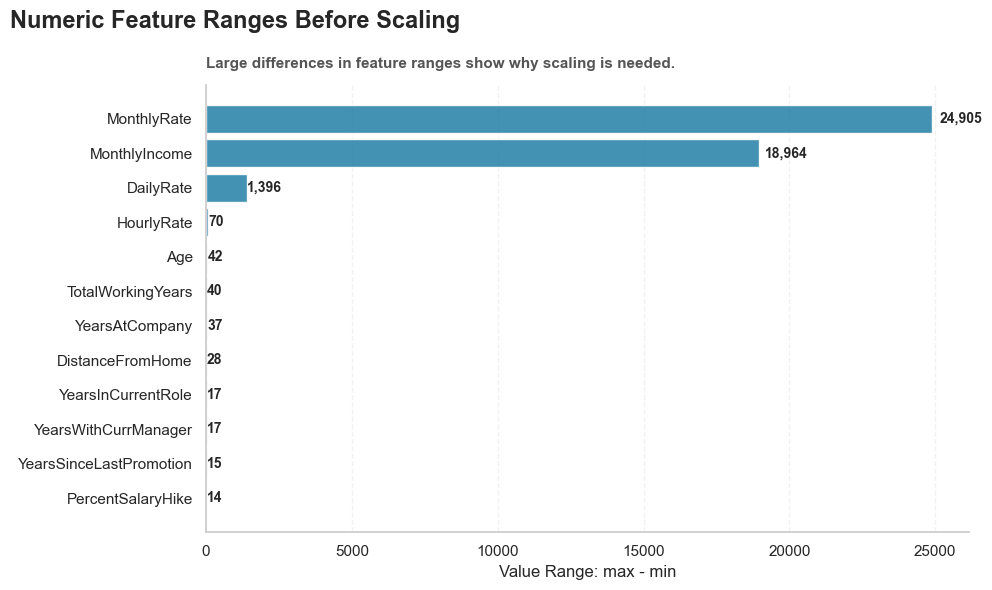

In [42]:
# Step 27: Visualize numeric feature ranges before scaling


# Create range column
range_plot_data = numeric_range_summary.copy()
range_plot_data["range"] = range_plot_data["max"] - range_plot_data["min"]

# Select top 12 features with largest ranges
range_plot_data = (
    range_plot_data
    .sort_values("range", ascending=True)
    .tail(12)
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    range_plot_data.index,
    range_plot_data["range"],
    color="#2E86AB",
    alpha=0.9
)

# Add labels
for bar, value in zip(bars, range_plot_data["range"]):
    ax.text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Numeric Feature Ranges Before Scaling",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Large differences in feature ranges show why scaling is needed.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Formatting
ax.set_xlabel("Value Range: max - min")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

## Conclusion: Numeric Feature Ranges Before Scaling

The numeric feature range chart shows that the dataset contains features with very different scales.

`MonthlyRate` has the largest range, followed by `MonthlyIncome` and `DailyRate`. These features have values in the thousands. In contrast, other features such as age, years at company, satisfaction scores, and performance ratings have much smaller ranges.

This difference in scale can affect machine learning models such as Logistic Regression. Features with larger numeric ranges may influence the model more strongly, not because they are necessarily more important, but because their values are larger.

To make the numeric features more comparable, scaling will be applied during preprocessing. Scaling does not change the business meaning of the data. It only transforms the numeric values into a more model-friendly format.

In [43]:
# Step 28: Compare StandardScaler, MinMaxScaler, RobustScaler on selected numeric features


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Select a few columns with different ranges
scaling_demo_features = [
    "MonthlyIncome",
    "Age",
    "DistanceFromHome",
    "JobSatisfaction",
    "YearsAtCompany"
]

# Use only training data to avoid data leakage
scaling_demo_data = X_train[scaling_demo_features].copy()

# Create scalers
scalers = {
    "Original": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

# Store transformed data
scaled_outputs = {}

for scaler_name, scaler in scalers.items():
    if scaler is None:
        scaled_outputs[scaler_name] = scaling_demo_data.copy()
    else:
        scaled_outputs[scaler_name] = pd.DataFrame(
            scaler.fit_transform(scaling_demo_data),
            columns=scaling_demo_features
        )

# Show summary statistics for each scaler
for scaler_name, data in scaled_outputs.items():
    print("=" * 80)
    print(scaler_name)
    print("=" * 80)
    display(data.describe().T[["min", "max", "mean", "std"]])

Original


,min,max,mean,std
MonthlyIncome,1009.000,19973.000,6548.270,4611.460
Age,18.000,60.000,36.946,9.165
DistanceFromHome,1.000,29.000,9.298,8.161
JobSatisfaction,1.000,4.000,2.707,1.109
YearsAtCompany,0.000,37.000,6.939,5.951


StandardScaler


,min,max,mean,std
MonthlyIncome,-1.202,2.913,-0.000,1.000
Age,-2.068,2.517,0.000,1.000
DistanceFromHome,-1.017,2.415,0.000,1.000
JobSatisfaction,-1.539,1.166,0.000,1.000
YearsAtCompany,-1.167,5.054,0.000,1.000


MinMaxScaler


,min,max,mean,std
MonthlyIncome,0.000,1.000,0.292,0.243
Age,0.000,1.000,0.451,0.218
DistanceFromHome,0.000,1.000,0.296,0.291
JobSatisfaction,0.000,1.000,0.569,0.370
YearsAtCompany,0.000,1.000,0.188,0.161


RobustScaler


,min,max,mean,std
MonthlyIncome,-0.744,2.735,0.272,0.846
Age,-1.385,1.846,0.073,0.705
DistanceFromHome,-0.500,1.833,0.192,0.680
JobSatisfaction,-1.000,0.500,-0.147,0.555
YearsAtCompany,-0.714,4.571,0.277,0.850


## Conclusion: Scaler Comparison

The scaler comparison shows how different preprocessing techniques transform numeric features.

In the original data, features have very different ranges. For example, `MonthlyIncome` ranges from **1,009 to 19,973**, while `JobSatisfaction` ranges only from **1 to 4**. Because of this, scaling is useful before training models such as Logistic Regression.

`StandardScaler` transforms features so that each column has an average close to **0** and a standard deviation close to **1**. This helps the model compare features on a similar scale.

`MinMaxScaler` transforms each feature into a fixed range between **0 and 1**. This makes all numeric columns behave like a percentage-style scale.

`RobustScaler` uses the median and middle range of the data. It is useful when features contain extreme values or outliers, such as income-related columns.

For this project, scaling should be fitted only on the training data to avoid data leakage. The test data should remain unseen during preprocessing and should only be transformed using the rules learned from the training data.

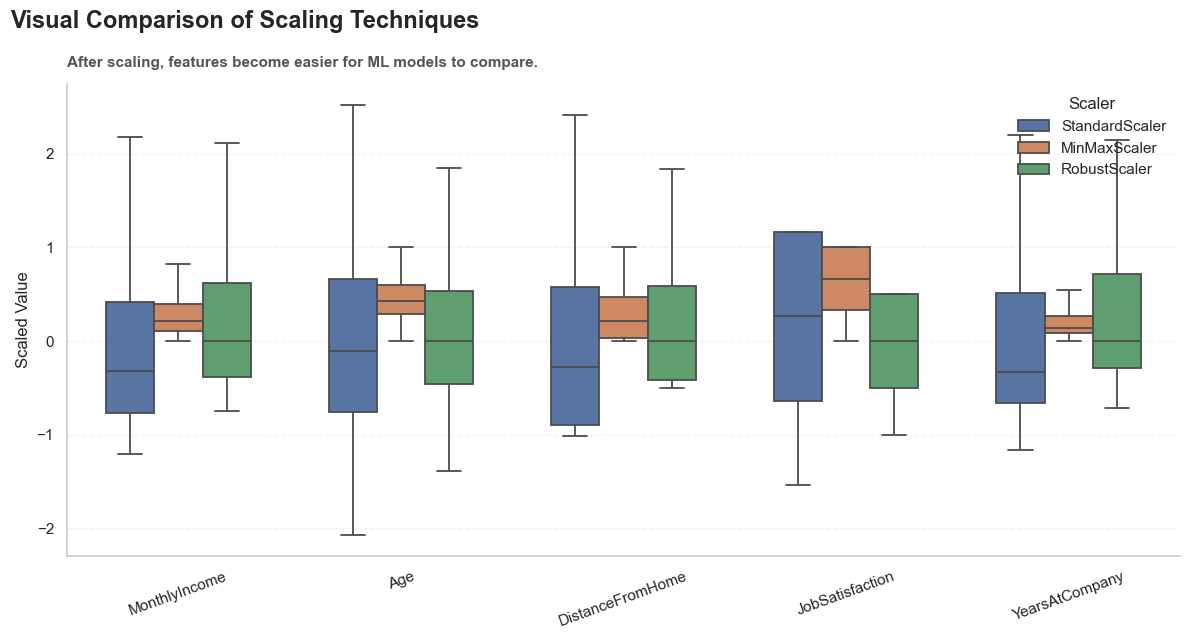

In [44]:
# Step 29: Visual comparison of scaler outputs


# Combine scaler outputs into one long-format table for plotting
scaler_plot_data = []

for scaler_name, data in scaled_outputs.items():
    temp = data.copy()
    temp["Scaler"] = scaler_name
    scaler_plot_data.append(temp)

scaler_plot_data = pd.concat(scaler_plot_data, ignore_index=True)

# Convert wide table to long table
scaler_plot_long = scaler_plot_data.melt(
    id_vars="Scaler",
    value_vars=scaling_demo_features,
    var_name="Feature",
    value_name="Value"
)

# Keep only scaled versions for cleaner comparison
scaled_only_plot = scaler_plot_long[
    scaler_plot_long["Scaler"] != "Original"
].copy()

# Create figure
fig, ax = plt.subplots(figsize=(12, 6.5))

sns.boxplot(
    data=scaled_only_plot,
    x="Feature",
    y="Value",
    hue="Scaler",
    width=0.65,
    linewidth=1.3,
    showfliers=False,
    ax=ax
)

# Titles
fig.suptitle(
    "Visual Comparison of Scaling Techniques",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "After scaling, features become easier for ML models to compare.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Formatting
ax.set_xlabel("")
ax.set_ylabel("Scaled Value")

ax.tick_params(axis="x", rotation=20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.legend(
    title="Scaler",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

## Conclusion: Visual Comparison of Scaling Techniques

The visual comparison shows how different scalers transform numeric features.

`StandardScaler` centers features around 0 and scales them so that the standard deviation is close to 1. This makes it useful for models such as Logistic Regression, SVM, KNN, PCA, and Neural Networks.

`MinMaxScaler` transforms values into a fixed range between 0 and 1. This makes all numeric columns comparable on a bounded scale.

`RobustScaler` uses the median and middle 50% of the data, making it more resistant to extreme values and outliers.

For this project, we will use `StandardScaler` as the main scaler because our first baseline model will be Logistic Regression, and StandardScaler is commonly used with this type of model.

In [45]:
# Step 30: Inspect categorical feature values


# Show unique values for each categorical column
for column in categorical_features:
    print("=" * 80)
    print(column)
    print("=" * 80)
    print(X_train[column].value_counts())
    print()

BusinessTravel
BusinessTravel
Travel_Rarely        732
Travel_Frequently    185
Non-Travel           112
Name: count, dtype: int64

Department
Department
Research & Development    668
Sales                     317
Human Resources            44
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       419
Medical             321
Marketing           116
Technical Degree    106
Other                49
Human Resources      18
Name: count, dtype: int64

Gender
Gender
Male      610
Female    419
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              239
Research Scientist           195
Laboratory Technician        182
Manufacturing Director       101
Healthcare Representative     95
Manager                       74
Research Director             54
Sales Representative          52
Human Resources               37
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     477
Single      324
Divorced    228
Name: count, dtype: int64

OverTime
OverTim

## Conclusion: Categorical Feature Inspection

The dataset contains **7 categorical features**: `BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, and `OverTime`.

These columns contain text-based categories, such as department names, job roles, marital status, and overtime status.

Machine learning models cannot directly understand text values like `Sales`, `Travel_Rarely`, or `Yes`. Therefore, these categorical columns need to be converted into numeric format before model training.

For this project, we will use **One-Hot Encoding**. One-hot encoding creates separate 0/1 columns for each category. This is useful because most categorical features in this dataset do not have a natural ranking or order.

For example, `OverTime` contains `Yes` and `No`. After one-hot encoding, the model receives numeric columns such as `OverTime_Yes` and `OverTime_No`.

This prepares the categorical features for machine learning while avoiding fake numeric rankings between categories.

| Feature          | Number of categories | Example values                                             |
| ---------------- | -------------------: | ---------------------------------------------------------- |
| `BusinessTravel` |                    3 | Travel_Rarely, Travel_Frequently, Non-Travel               |
| `Department`     |                    3 | R&D, Sales, HR                                             |
| `EducationField` |                    6 | Life Sciences, Medical, Marketing                          |
| `Gender`         |                    2 | Male, Female                                               |
| `JobRole`        |                    9 | Sales Executive, Research Scientist, Laboratory Technician |
| `MaritalStatus`  |                    3 | Married, Single, Divorced                                  |
| `OverTime`       |                    2 | Yes, No                                                    |


| OverTime_No | OverTime_Yes |
| ----------: | -----------: |
|           0 |            1 |
|           1 |            0 |
|           1 |            0 |
|           0 |            1 |

#### after encoding

In [47]:
# Step 31: Demonstrate One-Hot Encoding properly



from sklearn.preprocessing import OneHotEncoder

# Select two categorical columns for demonstration
encoding_demo_features = ["BusinessTravel", "OverTime"]

# Build a small demo sample that includes:
# - all BusinessTravel categories
# - both OverTime categories
encoding_demo_data = (
    X_train[encoding_demo_features]
    .drop_duplicates()
    .sort_values(encoding_demo_features)
    .reset_index(drop=True)
)

print("Original categorical demo data:")
display(encoding_demo_data)

# Create OneHotEncoder
onehot_demo = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

# Fit and transform the demo data
encoded_array = onehot_demo.fit_transform(encoding_demo_data)

# Get new encoded column names
encoded_column_names = onehot_demo.get_feature_names_out(encoding_demo_features)

# Convert encoded output into a readable DataFrame
encoded_demo_df = pd.DataFrame(
    encoded_array,
    columns=encoded_column_names,
    index=encoding_demo_data.index
)

print("After One-Hot Encoding:")
display(encoded_demo_df)

Original categorical demo data:


,BusinessTravel,OverTime
0,Non-Travel,No
1,Non-Travel,Yes
2,Travel_Frequently,No
3,Travel_Frequently,Yes
4,Travel_Rarely,No
5,Travel_Rarely,Yes


After One-Hot Encoding:


,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,OverTime_No,OverTime_Yes
0,1.000,0.000,0.000,1.000,0.000
1,1.000,0.000,0.000,0.000,1.000
2,0.000,1.000,0.000,1.000,0.000
3,0.000,1.000,0.000,0.000,1.000
4,0.000,0.000,1.000,1.000,0.000
5,0.000,0.000,1.000,0.000,1.000


## Conclusion: Complete One-Hot Encoding Demo

This demo shows how One-Hot Encoding converts categorical text values into numeric columns.

The original demo data included all important values from two categorical features: `BusinessTravel` and `OverTime`.

`BusinessTravel` contains three categories: `Non-Travel`, `Travel_Frequently`, and `Travel_Rarely`. After One-Hot Encoding, these became three separate numeric columns.

`OverTime` contains two categories: `No` and `Yes`. After One-Hot Encoding, these became two separate numeric columns.

Each encoded column contains only `0` or `1`. A value of `1` means the employee belongs to that category, while `0` means the employee does not belong to that category.

This allows machine learning models to use categorical information without creating a false ranking between categories.

In [48]:
# Step 32: Build numeric and categorical preprocessing pipelines


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric pipeline:
# 1. Fill missing numeric values with median
# 2. Scale numeric features using StandardScaler
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline:
# 1. Fill missing categorical values with most frequent value
# 2. Convert categories into 0/1 columns using OneHotEncoder
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer applies:
# - numeric_pipeline to numeric_features
# - categorical_pipeline to categorical_features
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully.")
print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Preprocessor created successfully.
Number of numeric features: 23
Number of categorical features: 7


## Conclusion: Preprocessing Pipeline

A preprocessing pipeline was created for both numeric and categorical features.

The numeric pipeline handles **23 numeric features**. It fills missing numeric values using the median and then applies `StandardScaler` to put numeric features on a comparable scale.

The categorical pipeline handles **7 categorical features**. It fills missing categorical values using the most frequent value and then applies `OneHotEncoder` to convert text categories into numeric 0/1 columns.

These two pipelines were combined using `ColumnTransformer`. This allows the correct preprocessing steps to be applied automatically to the correct columns.

Even though this dataset does not currently contain missing values, imputers are included to make the workflow safer and more professional for future data.

This preprocessing setup prepares the dataset for machine learning while reducing manual work and helping avoid data leakage.

In [49]:
# Step 33: Fit and transform training data with the preprocessor


# Fit the preprocessor on training data only
# Then transform the training data
X_train_preprocessed = preprocessor.fit_transform(X_train)

print("Original X_train shape:", X_train.shape)
print("Preprocessed X_train shape:", X_train_preprocessed.shape)
print("Type after preprocessing:", type(X_train_preprocessed))

Original X_train shape: (1029, 30)
Preprocessed X_train shape: (1029, 51)
Type after preprocessing: <class 'numpy.ndarray'>


## Conclusion: Applying the Preprocessor

The preprocessing pipeline was successfully applied to the training data.

The original training dataset had **1029 rows and 30 input columns**. After preprocessing, it still has **1029 rows**, but the number of columns increased to **51**.

The increase in columns happens because categorical features were transformed using One-Hot Encoding. One categorical column can become multiple numeric 0/1 columns, depending on how many categories it contains.

The output is a NumPy array, which means the data has been converted into a numeric format that machine learning models can use.

This confirms that the preprocessing pipeline is working correctly.

In [50]:
# Step 34: Get transformed feature names | 51 column names after preprocessing


# Get names of numeric features after preprocessing
numeric_output_features = numeric_features

# Get names of one-hot encoded categorical features
categorical_output_features = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

# Combine numeric and categorical output names
final_feature_names = numeric_output_features + categorical_output_features

print("Total transformed features:", len(final_feature_names))

# Display final feature names
final_feature_names

Total transformed features: 51


['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'BusinessTravel_Non-Travel',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Human Resources',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Human Resources',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Female',
 'Gender_Male',
 'JobRole_Healthcare Representative',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'Job

## Conclusion: Transformed Feature Names

After preprocessing, the model receives **51 transformed input features**.

The original numeric features remain as individual columns, but they are scaled using `StandardScaler`.

The categorical features are expanded into multiple One-Hot Encoded columns. For example, `OverTime` becomes `OverTime_No` and `OverTime_Yes`, while `JobRole` becomes separate columns for each job role.

This transformation converts the dataset into a fully numeric format that machine learning models can understand.

The increase from **30 original input columns** to **51 transformed columns** happens because categorical variables are expanded into multiple 0/1 indicator columns.

In [51]:
# Step 35: Convert preprocessed training data into a readable DataFrame


X_train_preprocessed_df = pd.DataFrame(
    X_train_preprocessed,
    columns=final_feature_names,
    index=X_train.index
)

print("Shape:", X_train_preprocessed_df.shape)

X_train_preprocessed_df.head()

Shape: (1029, 51)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
853,-1.959,-0.414,-0.037,-0.866,0.270,-0.548,0.378,-0.998,-1.539,-0.867,-1.009,-0.689,2.691,2.339,0.235,-0.935,-1.343,1.015,0.336,-0.998,-0.903,-0.680,-1.169,0.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000
435,-0.431,1.176,0.699,-1.836,-0.651,-0.450,0.378,0.846,0.265,1.532,1.405,1.715,-0.878,-0.428,1.154,-0.935,0.478,-0.598,1.735,0.010,0.493,1.493,0.812,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000
587,1.643,1.297,0.209,1.073,1.192,0.829,0.378,-0.076,0.265,-0.737,1.018,2.115,1.319,2.339,-0.684,0.247,-0.302,0.209,0.336,-0.326,-0.623,-0.369,-0.037,0.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000
1170,-1.086,-0.550,-0.895,0.104,1.192,1.075,0.378,-0.998,1.166,-0.861,-1.130,-0.288,-0.603,-0.428,0.235,-0.935,-0.693,-2.212,-1.063,-0.494,-0.623,-0.369,-0.603,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000
159,-0.322,-1.274,-0.895,1.073,0.270,0.485,0.378,-0.998,0.265,-0.937,-0.436,1.314,0.770,-0.428,1.154,0.247,-0.693,0.209,0.336,-0.494,-0.344,-0.369,-0.603,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000


## Conclusion: Preprocessed Training Data

The preprocessed training data was converted into a readable DataFrame with **1029 rows and 51 columns**.

Numeric features were transformed using `StandardScaler`, so their values are now centered around 0. A value close to 0 means the employee is close to the average for that feature. Positive values mean above average, and negative values mean below average.

Categorical features were transformed using One-Hot Encoding. These columns contain only 0 and 1. A value of 1 means the employee belongs to that category, while 0 means the employee does not belong to that category.

The dataset is now fully numeric and ready for machine learning models.

Why some values look strange?

Age = -1.959
MonthlyIncome = -0.867
JobSatisfaction = -1.539

This is because numeric columns were transformed using StandardScaler.
StandardScaler changes numbers into:

How far is this value from the average?

|   Scaled value | Meaning          |
| -------------: | ---------------- |
|            `0` | close to average |
| positive value | above average    |
| negative value | below average    |


In [52]:
# Step 36: Build baseline ML pipeline


from sklearn.linear_model import LogisticRegression

# Full pipeline:
# 1. Preprocess the data
# 2. Train Logistic Regression model
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

print("Baseline pipeline created successfully.")

Baseline pipeline created successfully.


## Conclusion: Baseline Machine Learning Pipeline

A baseline machine learning pipeline was created using two main steps: preprocessing and modeling.

The preprocessing step prepares the data by scaling numeric features and one-hot encoding categorical features. The model step uses Logistic Regression to predict employee attrition.

Logistic Regression is used as the first baseline model because it is simple, explainable, and suitable for binary classification problems such as predicting whether an employee will stay or leave.

The parameter `class_weight="balanced"` was added because the dataset is imbalanced. Since fewer employees left than stayed, this setting helps the model pay more attention to the minority class, which is the employees who left.

Using a pipeline is professional because it keeps preprocessing and modeling together, applies the same transformations consistently, and reduces the risk of data leakage.

Pipeline has two parts:

1. preprocessor
2. Logistic Regression model

When we train it, it will automatically do:

raw employee data
        ↓
fill missing values
        ↓
scale numeric columns
        ↓
one-hot encode categorical columns
        ↓
train Logistic Regression


without pipeline:

- scale test data incorrectly
- encode train and test data differently
- leak information from test data
- forget a preprocessing step later

In [53]:
# Step 37: Train the baseline model


# Train the full pipeline on the training data
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


## Conclusion: Training the Baseline Model

The baseline machine learning model was successfully trained on the training dataset.

During training, the full pipeline first applied preprocessing to the input features. Numeric features were scaled, and categorical features were one-hot encoded. After preprocessing, Logistic Regression learned patterns from the training data to predict employee attrition.

The model has learned only from the training data. The test data has not been used for learning, which is important because the test set should represent unseen data.

The next step is to evaluate the trained model on the test set to understand how well it performs on new employee data.


***Pipeline did this:***

- Training data
    ↓
- preprocessing fitted on X_train
    ↓
- numeric features scaled
    ↓
- categorical features one-hot encoded
    ↓
- Logistic Regression learned patterns

The model has now learned from the training employees.

It has not yet been evaluated on the test data.

In [54]:
# Step 38: Evaluate baseline model on test data


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predict class labels on test data
y_pred_baseline = baseline_model.predict(X_test)

# Predict probabilities for the positive class: Attrition = 1
y_pred_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "F1 Score": f1_score(y_test, y_pred_baseline),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_baseline)
}

baseline_metrics_df = pd.DataFrame(
    baseline_metrics.items(),
    columns=["Metric", "Score"]
)

display(baseline_metrics_df)

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Stayed", "Left"]
))

,Metric,Score
0,Accuracy,0.764
1,Precision,0.372
2,Recall,0.676
3,F1 Score,0.480
4,ROC-AUC,0.816


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.78      0.85       370
        Left       0.37      0.68      0.48        71

    accuracy                           0.76       441
   macro avg       0.65      0.73      0.66       441
weighted avg       0.84      0.76      0.79       441



| Metric    | Score | Simple meaning                                                  |
| --------- | ----: | --------------------------------------------------------------- |
| Accuracy  | 0.764 | Overall, model predicted correctly 76.4% of the time            |
| Precision | 0.372 | When model predicted “Left,” it was correct 37.2% of the time   |
| Recall    | 0.676 | Model caught 67.6% of actual employees who left                 |
| F1 Score  | 0.480 | Balance between precision and recall                            |
| ROC-AUC   | 0.816 | Model has good overall ability to separate leavers from stayers |


## Conclusion: Baseline Model Evaluation

The baseline Logistic Regression model was evaluated on the test dataset.

The model achieved an accuracy of **76.4%**, which means it correctly predicted the overall outcome for about three out of four employees.

However, because this is an imbalanced classification problem, accuracy alone is not enough. The more important metrics are recall, precision, F1-score, and ROC-AUC.

For employees who actually left, the model achieved a recall of **67.6%**. This means the model successfully identified about **68% of real leavers**. This is useful in an HR attrition context because the business wants to detect employees who may be at risk of leaving.

The precision for the `Left` class is **37.2%**. This means that when the model predicts an employee may leave, it is correct around 37% of the time. This indicates that the model catches many leavers but also produces some false alarms.

The F1-score is **48.0%**, which reflects the balance between precision and recall. The ROC-AUC score is **81.6%**, showing that the model has good overall ability to separate employees who leave from those who stay.

Overall, this is a reasonable baseline model. It is especially useful because it captures a good share of actual leavers, but there is room to improve precision and F1-score.

,Predicted Stayed,Predicted Left
Actual Stayed,289,81
Actual Left,23,48


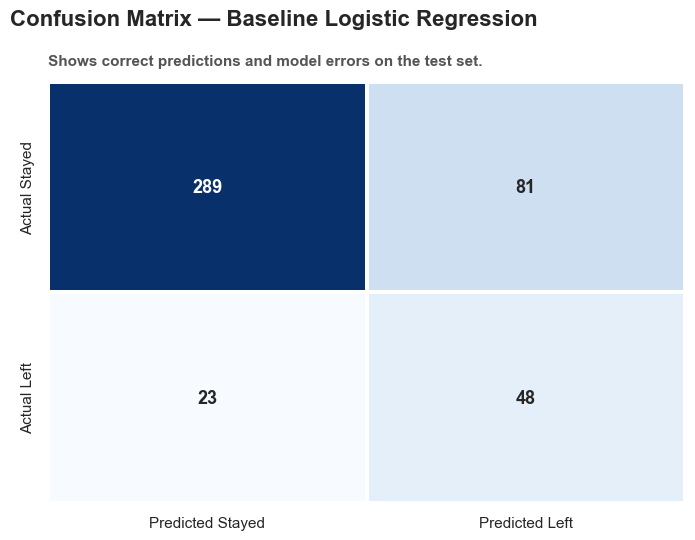

In [55]:
# Step 39: Confusion matrix for baseline model


from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

# Convert to readable DataFrame
cm_df = pd.DataFrame(
    cm,
    index=["Actual Stayed", "Actual Left"],
    columns=["Predicted Stayed", "Predicted Left"]
)

display(cm_df)

# Create figure
fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1.5,
    linecolor="white",
    cbar=False,
    annot_kws={"fontsize": 13, "fontweight": "bold"},
    ax=ax
)

# Titles
fig.suptitle(
    "Confusion Matrix — Baseline Logistic Regression",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Shows correct predictions and model errors on the test set.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### How to read confusin matrix

|               | Predicted Stayed | Predicted Left |
| ------------- | ---------------: | -------------: |
| Actual Stayed |              289 |             81 |
| Actual Left   |               23 |             48 |


Meaning of each box
1. Correctly predicted stayed: 289
Actual Stayed + Predicted Stayed = 289

The model correctly identified 289 employees who stayed.

2. False alarms: 81
Actual Stayed + Predicted Left = 81

The model predicted these employees would leave, but they actually stayed.

These are called False Positives.

Business meaning:

HR may unnecessarily focus on some employees who were not actually going to leave.

3. Missed leavers: 23
Actual Left + Predicted Stayed = 23

The model predicted these employees would stay, but they actually left.

These are called False Negatives.

Business meaning:

These are risky because HR missed employees who actually left.

4. Correctly caught leavers: 48
Actual Left + Predicted Left = 48

The model correctly identified 48 employees who left.

This is why recall is:

48 / (48 + 23) = 67.6%

So the model caught about 68% of actual leavers.

## Conclusion: Confusion Matrix

The confusion matrix shows how the baseline Logistic Regression model performed on the test dataset.

The model correctly predicted **289 employees who stayed** and correctly identified **48 employees who left**.

The model also made two types of errors. It predicted that **81 employees would leave**, but they actually stayed. These are false positives, or false alarms. It also predicted that **23 employees would stay**, but they actually left. These are false negatives, or missed leavers.

For this HR attrition project, false negatives are especially important because they represent employees who actually left but were not identified by the model as risky.

The model correctly caught **48 out of 71 actual leavers**, giving a recall of **67.6%**. This means the model is useful as an early-warning system, but it also produces a number of false alarms.

Overall, the confusion matrix confirms that the baseline model is reasonable, but there is room to improve precision, F1-score, and the balance between catching leavers and reducing false alarms.

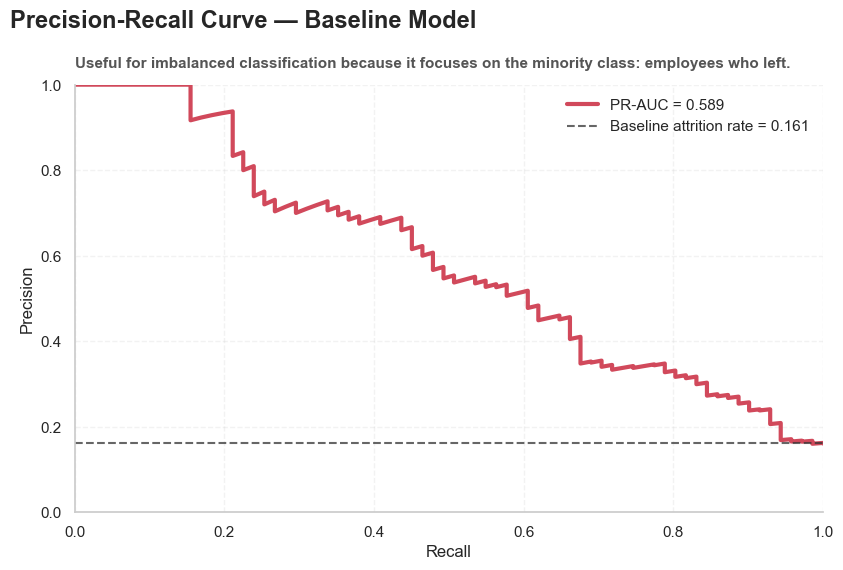

PR-AUC: 0.589


In [56]:
# Step 40: Precision-Recall curve for baseline model
# Because this dataset is imbalanced, a Precision-Recall curve is very useful.

from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision and recall at different probability thresholds
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_pred_proba_baseline
)

# Average Precision is the area under the Precision-Recall curve
pr_auc_baseline = average_precision_score(
    y_test,
    y_pred_proba_baseline
)

# Create figure
fig, ax = plt.subplots(figsize=(8.5, 5.8))

ax.plot(
    recall_values,
    precision_values,
    color="#D1495B",
    linewidth=3,
    label=f"PR-AUC = {pr_auc_baseline:.3f}"
)

# Baseline reference: attrition rate in test data
baseline_attrition_rate = y_test.mean()

ax.axhline(
    baseline_attrition_rate,
    color="#333333",
    linestyle="--",
    linewidth=1.5,
    alpha=0.75,
    label=f"Baseline attrition rate = {baseline_attrition_rate:.3f}"
)

# Titles
fig.suptitle(
    "Precision-Recall Curve — Baseline Model",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Useful for imbalanced classification because it focuses on the minority class: employees who left.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(linestyle="--", alpha=0.25)

ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

print(f"PR-AUC: {pr_auc_baseline:.3f}")

## Conclusion: Precision-Recall Curve

The Precision-Recall curve evaluates how well the model identifies employees who are likely to leave.

The model achieved a **PR-AUC of 0.589**. This is much higher than the baseline attrition rate of **0.161**, which represents the expected precision from random guessing.

This means the model is learning useful patterns and is better than random prediction at identifying employees who may leave.

The curve also shows the trade-off between precision and recall. When recall increases, the model catches more real leavers, but precision usually decreases, meaning there are more false alarms.

In an HR attrition context, this trade-off is important. If the company wants to catch more employees at risk of leaving, it may accept more false positives. If the company wants fewer false alarms, it may accept lower recall.

Overall, the Precision-Recall curve shows that the baseline model has useful predictive power, especially for identifying employees at risk of attrition.

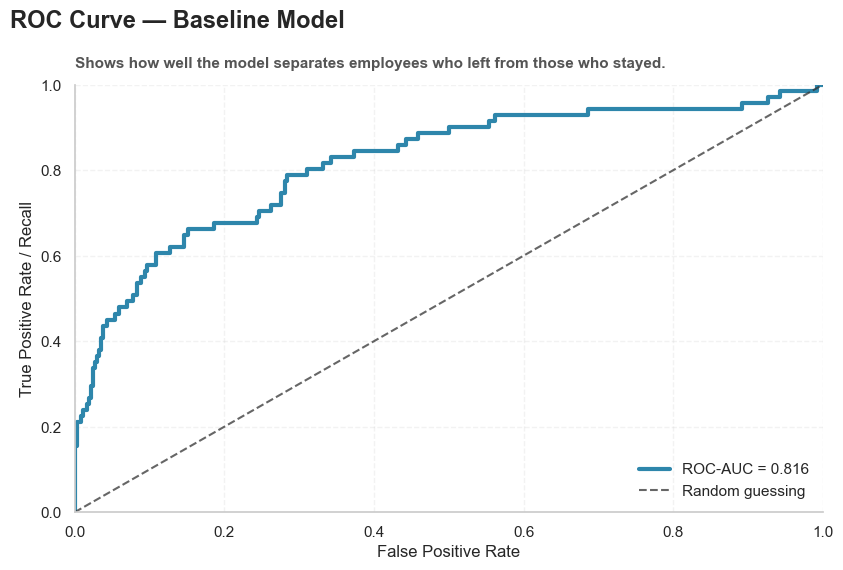

ROC-AUC: 0.816


In [57]:
# Step 41: ROC curve for baseline model


from sklearn.metrics import roc_curve, auc

# Calculate false positive rate and true positive rate
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_pred_proba_baseline
)

# Calculate ROC-AUC
roc_auc_baseline = auc(fpr, tpr)

# Create figure
fig, ax = plt.subplots(figsize=(8.5, 5.8))

# ROC curve
ax.plot(
    fpr,
    tpr,
    color="#2E86AB",
    linewidth=3,
    label=f"ROC-AUC = {roc_auc_baseline:.3f}"
)

# Random guessing line
ax.plot(
    [0, 1],
    [0, 1],
    color="#333333",
    linestyle="--",
    linewidth=1.5,
    alpha=0.75,
    label="Random guessing"
)

# Titles
fig.suptitle(
    "ROC Curve — Baseline Model",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Shows how well the model separates employees who left from those who stayed.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(linestyle="--", alpha=0.25)

ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_baseline:.3f}")

Step 41 — ROC Curve
What is ROC-AUC?

ROC-AUC checks how well the model separates:

Employees who stayed
vs
Employees who left

A simple way to understand:

|   ROC-AUC | Meaning         |
| --------: | --------------- |
|      0.50 | Random guessing |
| 0.70–0.80 | Decent          |
| 0.80–0.90 | Good            |
|     0.90+ | Very strong     |


Your baseline model already had:

ROC-AUC = 0.816

ROC Curve Compares:

True Positive Rate = how many leavers we catch
False Positive Rate = how many stayers we wrongly flag

Interpretation

Your ROC-AUC is:

0.816

This is good for a first baseline model.

Simple meaning

The dashed diagonal line represents random guessing.

Your blue ROC curve is clearly above that line, which means:

The model is much better than random guessing at separating employees who left from employees who stayed.

Business meaning

The model is reasonably good at ranking employees by attrition risk.

For example, if the model gives one employee a higher attrition probability than another employee, there is a good chance that the higher-risk employee is genuinely more likely to leave.

However, ROC-AUC does not directly tell us how many false alarms HR will get. That is why we also looked at the Precision-Recall curve and confusion matrix.

For imbalanced HR attrition problems, we should consider all three together:

| Evaluation view        | What it tells us                        |
| ---------------------- | --------------------------------------- |
| Confusion matrix       | Exact correct and wrong predictions     |
| Precision-Recall curve | Quality of detecting the minority class |
| ROC curve              | Overall separation ability              |


## Conclusion: ROC Curve

The ROC curve evaluates how well the baseline model separates employees who left from employees who stayed.

The baseline Logistic Regression model achieved a **ROC-AUC score of 0.816**. This is clearly better than random guessing, which would have a ROC-AUC close to **0.50**.

The ROC curve is above the diagonal random-guessing line, showing that the model has useful predictive power.

This means the model is reasonably good at ranking employees by attrition risk. Employees with higher predicted attrition probabilities are more likely to belong to the group that actually left.

However, ROC-AUC alone is not enough for an imbalanced HR attrition problem. It should be interpreted together with recall, precision, F1-score, the confusion matrix, and the Precision-Recall curve.

In [58]:
# Step 42: Create custom transformer for feature engineering


from sklearn.base import BaseEstimator, TransformerMixin

class JobSatisfactionYearsTransformer(BaseEstimator, TransformerMixin):
    """
    Custom sklearn transformer that creates an interaction feature:
    JobSatisfaction_x_YearsAtCompany
    
    This feature is calculated as:
    JobSatisfaction * YearsAtCompany
    """
    
    def __init__(self):
        # No settings are needed for this transformer
        pass
    
    def fit(self, X, y=None):
        # fit() is required by sklearn.
        # This transformer does not need to learn anything from the data.
        return self
    
    def transform(self, X):
        # Create a copy so we do not change the original dataset directly
        X_transformed = X.copy()
        
        # Create the new interaction feature
        X_transformed["JobSatisfaction_x_YearsAtCompany"] = (
            X_transformed["JobSatisfaction"] * X_transformed["YearsAtCompany"]
        )
        
        return X_transformed


# Test the transformer on a small sample
feature_engineer = JobSatisfactionYearsTransformer()

demo_transformed = feature_engineer.fit_transform(
    X_train[["JobSatisfaction", "YearsAtCompany"]].head(10)
)

demo_transformed

,JobSatisfaction,YearsAtCompany,JobSatisfaction_x_YearsAtCompany
853,1,1,1
435,3,7,21
587,3,5,15
1170,4,4,16
159,3,4,12
5,4,7,28
298,4,1,4
116,1,11,11
807,3,8,24
139,4,11,44


## Conclusion: Custom Transformer for Feature Engineering

A custom sklearn transformer was created to add a new interaction feature called `JobSatisfaction_x_YearsAtCompany`.

This feature is calculated by multiplying `JobSatisfaction` with `YearsAtCompany`.

The transformer successfully added the new column to the dataset. For example, an employee with `JobSatisfaction = 3` and `YearsAtCompany = 7` receives a new feature value of `21`.

This type of feature is called an interaction feature because it combines information from two existing columns. The goal is to help the model learn patterns that may not be fully captured when the two features are used separately.

Using a custom transformer is useful because it allows feature engineering to be included directly inside the machine learning pipeline.

In [59]:
# Step 43: Build model pipeline with custom transformer


# Add the new engineered feature to the numeric feature list
numeric_features_with_engineered = numeric_features + [
    "JobSatisfaction_x_YearsAtCompany"
]

# Build a new preprocessor that knows about the engineered feature
preprocessor_with_engineered_feature = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features_with_engineered),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

# Full pipeline with custom transformer:
# 1. Add engineered feature
# 2. Apply preprocessing
# 3. Train Logistic Regression model
model_with_engineered_feature = Pipeline(steps=[
    ("feature_engineering", JobSatisfactionYearsTransformer()),
    ("preprocessor", preprocessor_with_engineered_feature),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

print("Pipeline with custom transformer created successfully.")
print("Original numeric features:", len(numeric_features))
print("Numeric features after engineering:", len(numeric_features_with_engineered))

Pipeline with custom transformer created successfully.
Original numeric features: 23
Numeric features after engineering: 24


What changed

Before feature engineering:

Before feature engineering:

Numeric features = 23

After adding the engineered feature:

Numeric features = 24

The new numeric feature is:

JobSatisfaction_x_YearsAtCompany

The new model pipeline works like this:

- Raw employee data
        ↓
- Custom transformer adds JobSatisfaction_x_YearsAtCompany
        ↓
- Numeric columns are imputed and scaled
        ↓
- Categorical columns are imputed and one-hot encoded
        ↓
- Logistic Regression model is trained

## Conclusion: Pipeline with Custom Transformer

A new machine learning pipeline was created with the custom feature engineering transformer as the first step.

The custom transformer adds a new numeric feature called `JobSatisfaction_x_YearsAtCompany`, which is calculated by multiplying `JobSatisfaction` with `YearsAtCompany`.

After adding this feature, the number of numeric features increased from **23 to 24**.

The pipeline now follows a professional workflow: first it creates the engineered feature, then it applies preprocessing, and finally it trains the Logistic Regression model.

This approach is useful because feature engineering is included directly inside the sklearn pipeline, making the workflow cleaner, reusable, and safer from data leakage.

In [60]:
# Step 44: Train and evaluate model with engineered feature


# Train the model with the engineered feature
model_with_engineered_feature.fit(X_train, y_train)

# Predict on test data
y_pred_engineered = model_with_engineered_feature.predict(X_test)

# Predict probabilities for Attrition = 1
y_pred_proba_engineered = model_with_engineered_feature.predict_proba(X_test)[:, 1]

# Calculate metrics
engineered_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_engineered),
    "Precision": precision_score(y_test, y_pred_engineered),
    "Recall": recall_score(y_test, y_pred_engineered),
    "F1 Score": f1_score(y_test, y_pred_engineered),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_engineered),
    "PR-AUC": average_precision_score(y_test, y_pred_proba_engineered)
}

engineered_metrics_df = pd.DataFrame(
    engineered_metrics.items(),
    columns=["Metric", "Score"]
)

display(engineered_metrics_df)

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_engineered,
    target_names=["Stayed", "Left"]
))

,Metric,Score
0,Accuracy,0.757
1,Precision,0.364
2,Recall,0.676
3,F1 Score,0.473
4,ROC-AUC,0.818
5,PR-AUC,0.588


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.77      0.84       370
        Left       0.36      0.68      0.47        71

    accuracy                           0.76       441
   macro avg       0.64      0.72      0.66       441
weighted avg       0.84      0.76      0.78       441



### What happened after adding the engineered feature?

Basline Model:

| Metric    | Baseline |
| --------- | -------: |
| Accuracy  |    0.764 |
| Precision |    0.372 |
| Recall    |    0.676 |
| F1 Score  |    0.480 |
| ROC-AUC   |    0.816 |
| PR-AUC    |    0.589 |

Model with JobSatisfaction_x_YearsAtCompany:

| Metric    | With engineered feature |
| --------- | ----------------------: |
| Accuracy  |                   0.757 |
| Precision |                   0.364 |
| Recall    |                   0.676 |
| F1 Score  |                   0.473 |
| ROC-AUC   |                   0.818 |
| PR-AUC    |                   0.588 |


Simple interpretation

The new feature did not improve the model much.

Recall stayed the same:

Baseline Recall = 0.676
Engineered Recall = 0.676

ROC-AUC improved slightly:

0.816 → 0.818

But accuracy, precision, F1-score, and PR-AUC became slightly lower.

So the correct professional conclusion is:

The engineered interaction feature did not meaningfully improve model performance for this Logistic Regression baseline.

That is still a valid and useful result.

In real machine learning, not every new feature improves the model. Testing and comparing is the correct professional approach.

## Conclusion: Model with Custom Engineered Feature

A second Logistic Regression pipeline was trained using the custom engineered feature `JobSatisfaction_x_YearsAtCompany`.

This feature was created by multiplying `JobSatisfaction` with `YearsAtCompany`, and it was added through a custom sklearn transformer inside the pipeline.

The model with the engineered feature achieved an accuracy of **75.7%**, precision of **36.4%**, recall of **67.6%**, F1-score of **47.3%**, ROC-AUC of **81.8%**, and PR-AUC of **58.8%**.

Compared with the baseline model, recall stayed the same at **67.6%**. ROC-AUC improved slightly from **81.6%** to **81.8%**, but accuracy, precision, F1-score, and PR-AUC decreased slightly.

This means the engineered feature did not meaningfully improve the Logistic Regression model. However, this is still a useful experiment because it shows how custom feature engineering can be integrated into a professional sklearn pipeline and evaluated objectively.

In machine learning, not every engineered feature improves performance. The correct approach is to test the feature, compare metrics, and decide based on evidence.

In [61]:
# Step 45: Compare baseline model vs engineered-feature model


# Add PR-AUC to baseline metrics for fair comparison
baseline_metrics_with_pr = baseline_metrics.copy()
baseline_metrics_with_pr["PR-AUC"] = pr_auc_baseline

# Convert both metric dictionaries into DataFrames
baseline_comparison_df = pd.DataFrame(
    baseline_metrics_with_pr.items(),
    columns=["Metric", "Baseline"]
)

engineered_comparison_df = pd.DataFrame(
    engineered_metrics.items(),
    columns=["Metric", "With Engineered Feature"]
)

# Merge the two model results
model_comparison_df = baseline_comparison_df.merge(
    engineered_comparison_df,
    on="Metric"
)

# Calculate difference
model_comparison_df["Difference"] = (
    model_comparison_df["With Engineered Feature"] 
    - model_comparison_df["Baseline"]
)

# Format for readability
model_comparison_df

,Metric,Baseline,With Engineered Feature,Difference
0,Accuracy,0.764,0.757,-0.007
1,Precision,0.372,0.364,-0.008
2,Recall,0.676,0.676,0.000
3,F1 Score,0.480,0.473,-0.007
4,ROC-AUC,0.816,0.818,0.001
5,PR-AUC,0.589,0.588,-0.000


## Conclusion: Baseline vs Custom Engineered Feature

The baseline Logistic Regression model was compared with a second model that included the custom engineered feature `JobSatisfaction_x_YearsAtCompany`.

The engineered feature was successfully added through a custom sklearn transformer and integrated into the machine learning pipeline.

However, the comparison shows that this engineered feature did not meaningfully improve model performance.

Accuracy decreased slightly from **76.4%** to **75.7%**. Precision decreased from **37.2%** to **36.4%**. Recall stayed exactly the same at **67.6%**. F1-score decreased slightly from **48.0%** to **47.3%**. ROC-AUC improved only slightly from **81.6%** to **81.8%**, while PR-AUC remained almost unchanged.

This means that the new interaction feature did not provide strong additional predictive value for this Logistic Regression baseline model.

This is still a valuable experiment because it demonstrates how custom feature engineering can be added safely inside a sklearn pipeline and evaluated objectively.

In machine learning, not every engineered feature improves performance. A professional workflow tests the feature, compares results, and decides based on evidence.

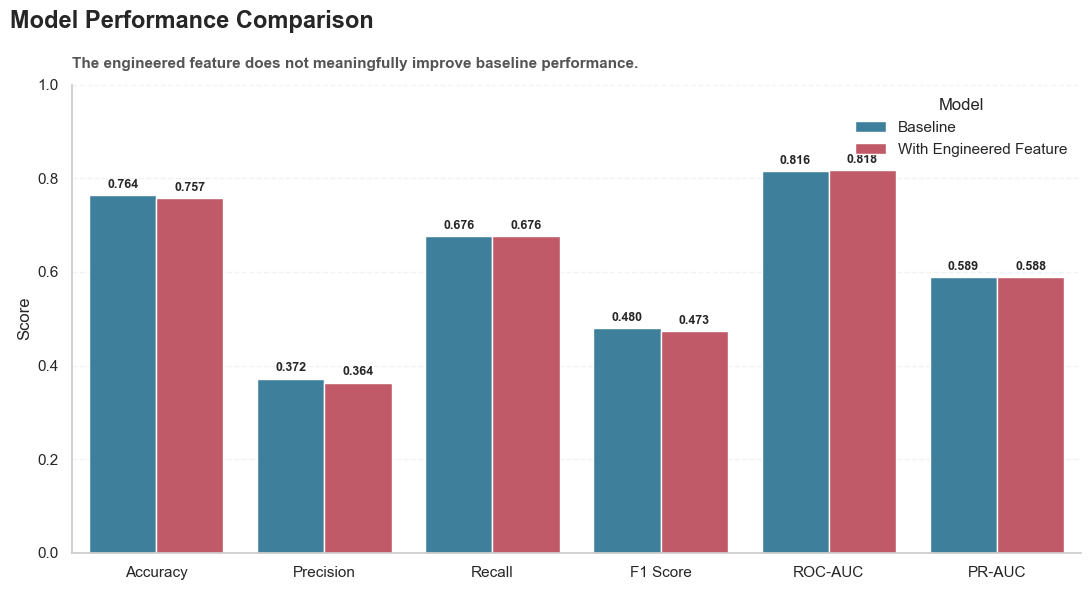

In [62]:
# Step 46: Vvisual comparison of baseline vs engineered model.


# Prepare data for plotting
comparison_plot_data = model_comparison_df.melt(
    id_vars="Metric",
    value_vars=["Baseline", "With Engineered Feature"],
    var_name="Model",
    value_name="Score"
)

# Create figure
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=comparison_plot_data,
    x="Metric",
    y="Score",
    hue="Model",
    palette={
        "Baseline": "#2E86AB",
        "With Engineered Feature": "#D1495B"
    },
    ax=ax
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Model Performance Comparison",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "The engineered feature does not meaningfully improve baseline performance.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Formatting
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.legend(
    title="Model",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

The important message is clear:

The custom engineered feature was added successfully, but it did not improve the model in a meaningful way.

The baseline model is slightly better on Accuracy, Precision, F1, and PR-AUC. The engineered-feature model is only very slightly better on ROC-AUC.

So for this Logistic Regression baseline, we should not claim improvement. We should say the feature was tested professionally, but the evidence does not justify keeping it as an improvement.

Paste this directly into a Markdown cell:

Conclusion: Visual Model Performance Comparison

The model performance comparison chart shows the baseline Logistic Regression model against the model with the custom engineered feature JobSatisfaction_x_YearsAtCompany.

The engineered feature was successfully added through a custom sklearn transformer and included inside the machine learning pipeline.

However, the visual comparison shows that the engineered feature did not meaningfully improve model performance.

The baseline model performs slightly better in Accuracy, Precision, F1-score, and PR-AUC. Recall remains exactly the same for both models at 67.6%. The engineered-feature model improves ROC-AUC only slightly from 81.6% to 81.8%, which is too small to be considered a meaningful improvement.

This result is still valuable because it demonstrates a professional machine learning workflow: create a feature, integrate it into a pipeline, compare performance, and make a decision based on evidence.

For this project, the custom transformer is useful as a learning and implementation exercise, but the engineered feature itself does not significantly improve the Logistic Regression baseline.

In [63]:
# Step 47: Check if category_encoders is installed


try:
    import category_encoders as ce
    print("category_encoders is installed.")
    print("Version:", ce.__version__)
except ImportError:
    print("category_encoders is NOT installed.")
    print("Install it by running this in a new notebook cell:")
    print("!pip install category_encoders")

category_encoders is installed.
Version: 2.8.1


# Target Encoding


What is TargetEncoder?

One-Hot Encoding creates many 0/1 columns.

Example:

JobRole_Sales Representative = 1
JobRole_Manager = 0
JobRole_Research Scientist = 0

Target Encoding works differently.

It replaces each category with the average target value for that category.

In our project:

Target = Attrition
0 = Stayed
1 = Left

So the average target value means:

average attrition rate for that category

Example:

If Sales Representatives have 39.8% attrition, TargetEncoder may encode:

JobRole = Sales Representative → 0.398

Simple meaning:

This job role has historically higher attrition risk.

Why TargetEncoder can cause data leakage

TargetEncoder uses the target column y.

That means it looks at the answer column:

Attrition

This is dangerous if done incorrectly.

Bad approach:

Fit TargetEncoder on full dataset before train-test split

Why bad?

Because the encoder has already seen information from the test data. That is like showing the model part of the exam answers before the exam.

Correct approach:

Fit TargetEncoder only on training data
Apply learned encoding to test data

This is why we use it inside a pipeline.

In [64]:
# Step 48: Demonstrate Target Encoding safely on training data


import category_encoders as ce

# Select one categorical feature for demonstration
target_encoding_demo_feature = ["JobRole"]

# Create a small copy from training data only
target_encoding_demo_data = X_train[target_encoding_demo_feature].copy()

# Create TargetEncoder
target_encoder_demo = ce.TargetEncoder(
    cols=target_encoding_demo_feature,
    smoothing=10
)

# Fit TargetEncoder only on training data
# Important: TargetEncoder needs y_train because it uses the target mean
target_encoder_demo.fit(target_encoding_demo_data, y_train)

# Transform the training data
target_encoded_demo = target_encoder_demo.transform(target_encoding_demo_data)

# Create a readable comparison table:
# original JobRole + encoded value
target_encoding_result = pd.DataFrame({
    "JobRole": target_encoding_demo_data["JobRole"],
    "JobRole_TargetEncoded": target_encoded_demo["JobRole"]
})

# Show average encoded value per job role
target_encoding_summary = (
    target_encoding_result
    .groupby("JobRole")
    .agg(
        encoded_value=("JobRole_TargetEncoded", "mean"),
        employee_count=("JobRole", "size")
    )
    .sort_values("encoded_value", ascending=False)
)

display(target_encoding_summary)

,encoded_value,employee_count
JobRole,,
Sales Representative,0.413,52
Laboratory Technician,0.264,182
Human Resources,0.231,37
Sales Executive,0.188,239
Research Scientist,0.133,195
Manufacturing Director,0.059,101
Manager,0.055,74
Healthcare Representative,0.053,95
Research Director,0.023,54


What your output means

You encoded JobRole using the average attrition risk from the training data.

The highest encoded values are:

| JobRole               | Encoded value | Meaning                 |
| --------------------- | ------------: | ----------------------- |
| Sales Representative  |         0.413 | Highest attrition risk  |
| Laboratory Technician |         0.264 | Higher attrition risk   |
| Human Resources       |         0.231 | Higher attrition risk   |
| Sales Executive       |         0.188 | Moderate attrition risk |
| Research Director     |         0.023 | Lowest attrition risk   |


Simple explanation

Sales Representative = 0.413 means:

In the training data, Sales Representatives have a high average attrition risk.

Research Director = 0.023 means:

In the training data, Research Directors have a low average attrition risk.

This matches what we saw earlier in EDA. Sales Representative was one of the highest-risk job roles.

Why this is different from One-Hot Encoding

One-Hot Encoding says:

JobRole_Sales Representative = 1 or 0

Target Encoding says:

JobRole = average attrition risk for that role

So Target Encoding gives the model more direct risk information.

But it is dangerous if done incorrectly because it uses the target column Attrition.

## Conclusion: Target Encoding Demo

Target Encoding was demonstrated using the `JobRole` column.

Unlike One-Hot Encoding, which creates separate 0/1 columns for each category, Target Encoding replaces each category with a value based on the average target value for that category.

In this project, the target is `Attrition`, where `1` means the employee left and `0` means the employee stayed. Therefore, the encoded value represents the approximate attrition risk for each job role in the training data.

For example, `Sales Representative` received the highest encoded value, showing that this role has a higher attrition risk in the training data. `Research Director` received one of the lowest encoded values, showing lower attrition risk.

Target Encoding can be powerful because it summarizes category risk in a compact numeric form. However, it must be used carefully because it uses the target variable. If Target Encoding is fitted on the full dataset before splitting, it can cause data leakage.

To reduce leakage risk, Target Encoding should be fitted only on the training data and applied to the test data through a pipeline.

### Build TargetEncoder pipeline

Now we build a new model pipeline using:

- Numeric columns → impute + scale
- Categorical columns → TargetEncoder
- Model → Logistic Regression

This version will use TargetEncoder instead of OneHotEncoder for categorical columns.

In [65]:
# Step 49: Build pipeline with TargetEncoder


import category_encoders as ce

# Numeric pipeline stays the same:
# Fill missing values and scale numeric columns
numeric_pipeline_target = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# TargetEncoder for categorical columns:
# It replaces categories with target-based numeric values.
target_encoder = ce.TargetEncoder(
    cols=categorical_features,
    smoothing=10,
    handle_unknown="value",
    handle_missing="value"
)

# ColumnTransformer:
# - numeric columns go through numeric pipeline
# - categorical columns go through TargetEncoder
preprocessor_target_encoder = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_target, numeric_features),
        ("target_encoded_categorical", target_encoder, categorical_features)
    ]
)

# Full pipeline:
# 1. Preprocess with TargetEncoder
# 2. Train Logistic Regression model
target_encoder_model = Pipeline(steps=[
    ("preprocessor", preprocessor_target_encoder),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

print("TargetEncoder pipeline created successfully.")
print("Numeric features:", len(numeric_features))
print("Categorical features target-encoded:", len(categorical_features))

TargetEncoder pipeline created successfully.
Numeric features: 23
Categorical features target-encoded: 7


What this means

You now have a third model pipeline:

- Raw employee data
        ↓
- Numeric columns: impute + scale
        ↓
- Categorical columns: TargetEncoder
        ↓
- Logistic Regression model

Instead of converting categories into many 0/1 columns like One-Hot Encoding, TargetEncoder converts each category into one numeric risk-like value.

Example idea:

JobRole = Sales Representative → high encoded value

JobRole = Research Director → low encoded value

This is useful because it can make categorical features more compact.

Important leakage point

This pipeline is safer because TargetEncoder is inside the sklearn pipeline. That means when we run:

target_encoder_model.fit(X_train, y_train)

the encoder learns category-risk values only from the training data.

Then when we use:

target_encoder_model.predict(X_test)

the test data is only transformed using rules learned from training data.

So the test answers are not used during encoding.

## Conclusion: TargetEncoder Pipeline

A new machine learning pipeline was created using `TargetEncoder` for categorical features.

In this pipeline, numeric features are imputed and scaled, while categorical features are transformed using Target Encoding.

Target Encoding replaces each category with a numeric value based on the average target value for that category. In this project, the target is `Attrition`, so the encoded values represent category-level attrition risk learned from the training data.

The pipeline uses **23 numeric features** and **7 target-encoded categorical features**.

Target Encoding can be powerful because it summarizes categorical risk in a compact numeric form. However, it must be used carefully because it uses the target variable during encoding.

By placing TargetEncoder inside the sklearn pipeline, the encoder is fitted only on the training data and then applied to the test data. This reduces the risk of data leakage.

In [66]:
# Step 50: Train and evaluate TargetEncoder model


# Train TargetEncoder model
target_encoder_model.fit(X_train, y_train)

# Predict labels on test data
y_pred_target_encoder = target_encoder_model.predict(X_test)

# Predict probabilities for Attrition = 1
y_pred_proba_target_encoder = target_encoder_model.predict_proba(X_test)[:, 1]

# Calculate metrics
target_encoder_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_target_encoder),
    "Precision": precision_score(y_test, y_pred_target_encoder),
    "Recall": recall_score(y_test, y_pred_target_encoder),
    "F1 Score": f1_score(y_test, y_pred_target_encoder),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_target_encoder),
    "PR-AUC": average_precision_score(y_test, y_pred_proba_target_encoder)
}

target_encoder_metrics_df = pd.DataFrame(
    target_encoder_metrics.items(),
    columns=["Metric", "Score"]
)

display(target_encoder_metrics_df)

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_target_encoder,
    target_names=["Stayed", "Left"]
))

,Metric,Score
0,Accuracy,0.753
1,Precision,0.358
2,Recall,0.676
3,F1 Score,0.468
4,ROC-AUC,0.787
5,PR-AUC,0.540


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.77      0.84       370
        Left       0.36      0.68      0.47        71

    accuracy                           0.75       441
   macro avg       0.64      0.72      0.65       441
weighted avg       0.83      0.75      0.78       441



## Conclusion: TargetEncoder Model Evaluation

A Logistic Regression model was trained using `TargetEncoder` for categorical features.

The TargetEncoder model achieved an accuracy of **75.3%**, precision of **35.8%**, recall of **67.6%**, F1-score of **46.8%**, ROC-AUC of **78.7%**, and PR-AUC of **54.0%**.

The recall remained the same as the baseline model, meaning the model still identified about **68% of actual leavers**. However, the TargetEncoder model performed worse than the One-Hot Encoding baseline on accuracy, precision, F1-score, ROC-AUC, and PR-AUC.

This means that TargetEncoder did not improve performance for this Logistic Regression model on this dataset.

However, this experiment is still valuable because it demonstrates how TargetEncoder works and how it can be integrated into a machine learning pipeline. Since TargetEncoder uses the target variable during encoding, it can cause data leakage if used incorrectly. Placing it inside the pipeline helps reduce this risk by fitting the encoder only on the training data and applying the learned encoding rules to the test data.

### Compare all three models

- Baseline OneHotEncoder
- Custom engineered feature
- TargetEncoder

In [67]:
# Step 51: Compare all model variants


# Create comparison DataFrames
baseline_all_df = pd.DataFrame(
    baseline_metrics_with_pr.items(),
    columns=["Metric", "Baseline OneHot"]
)

engineered_all_df = pd.DataFrame(
    engineered_metrics.items(),
    columns=["Metric", "Custom Feature"]
)

target_encoder_all_df = pd.DataFrame(
    target_encoder_metrics.items(),
    columns=["Metric", "TargetEncoder"]
)

# Merge all model metrics
all_models_comparison_df = (
    baseline_all_df
    .merge(engineered_all_df, on="Metric")
    .merge(target_encoder_all_df, on="Metric")
)

# Identify best model score for each metric
all_models_comparison_df["Best Score"] = all_models_comparison_df[
    ["Baseline OneHot", "Custom Feature", "TargetEncoder"]
].max(axis=1)

all_models_comparison_df

,Metric,Baseline OneHot,Custom Feature,TargetEncoder,Best Score
0,Accuracy,0.764,0.757,0.753,0.764
1,Precision,0.372,0.364,0.358,0.372
2,Recall,0.676,0.676,0.676,0.676
3,F1 Score,0.480,0.473,0.468,0.480
4,ROC-AUC,0.816,0.818,0.787,0.818
5,PR-AUC,0.589,0.588,0.540,0.589


Simple meaning

The Baseline OneHot model is the best overall model.

The custom feature model only improves ROC-AUC very slightly:

0.816 → 0.818

But this improvement is tiny, and the other important metrics become slightly worse.

The TargetEncoder model performs worse than the baseline on most metrics.

So the honest professional conclusion is:

For this dataset and Logistic Regression model, the baseline pipeline using OneHotEncoder performs best overall.

Paste this into a Markdown cell:

## Conclusion: Comparison of All Model Variants

Three Logistic Regression model variants were compared:

1. Baseline model using `OneHotEncoder`
2. Model with the custom engineered feature `JobSatisfaction_x_YearsAtCompany`
3. Model using `TargetEncoder` for categorical features

The baseline OneHotEncoder model performs best overall. It achieved the highest accuracy, precision, F1-score, and PR-AUC.

All three models achieved the same recall of **67.6%**, meaning they identified the same proportion of actual leavers.

The custom engineered feature model achieved the highest ROC-AUC score of **81.8%**, compared with **81.6%** for the baseline. However, this improvement is very small and does not outweigh the slight decreases in accuracy, precision, F1-score, and PR-AUC.

The TargetEncoder model did not improve performance in this experiment. It performed worse than the baseline on accuracy, precision, F1-score, ROC-AUC, and PR-AUC.

Overall, the baseline OneHotEncoder pipeline is the best model among the three tested options. The custom transformer and TargetEncoder experiments are still valuable because they demonstrate professional feature engineering, pipeline integration, leakage-aware preprocessing, and evidence-based model comparison.

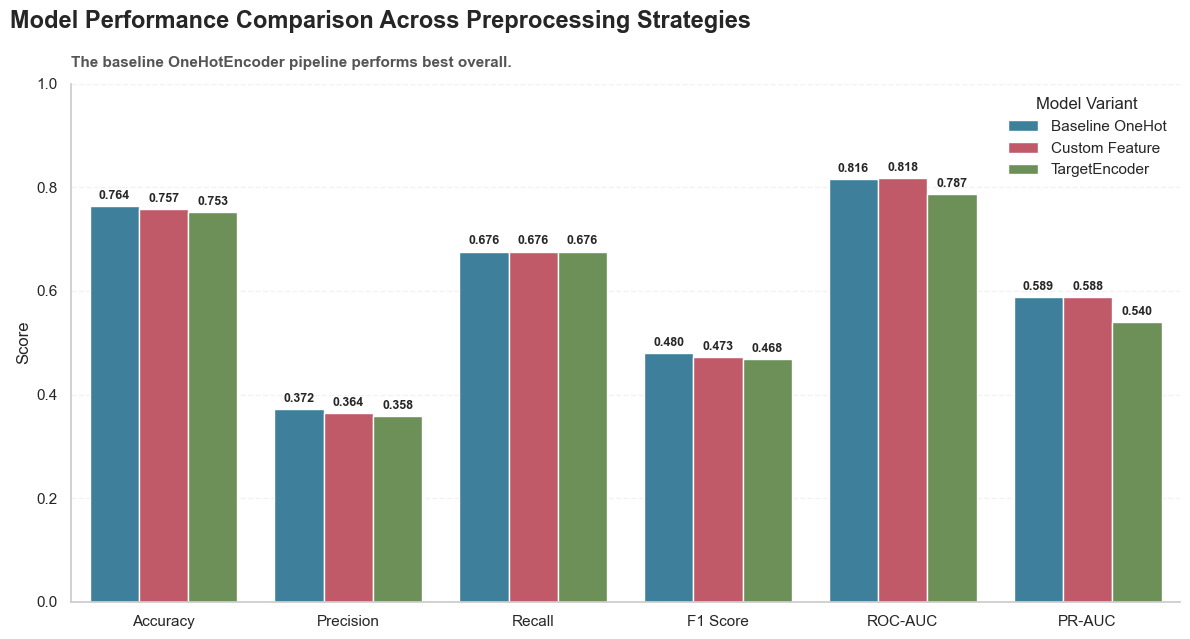

In [68]:
# Step 52: Visual comparison of all model variants


# Prepare data for plotting
all_models_plot_data = all_models_comparison_df.melt(
    id_vars="Metric",
    value_vars=["Baseline OneHot", "Custom Feature", "TargetEncoder"],
    var_name="Model",
    value_name="Score"
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6.5))

sns.barplot(
    data=all_models_plot_data,
    x="Metric",
    y="Score",
    hue="Model",
    palette={
        "Baseline OneHot": "#2E86AB",
        "Custom Feature": "#D1495B",
        "TargetEncoder": "#6A994E"
    },
    ax=ax
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Model Performance Comparison Across Preprocessing Strategies",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "The baseline OneHotEncoder pipeline performs best overall.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.legend(
    title="Model Variant",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

## Conclusion: Visual Comparison of Model Variants

The model comparison chart shows the performance of three Logistic Regression pipelines:

1. Baseline model using `OneHotEncoder`
2. Model with the custom engineered feature `JobSatisfaction_x_YearsAtCompany`
3. Model using `TargetEncoder`

The baseline OneHotEncoder model performs best overall. It has the highest accuracy, precision, F1-score, and PR-AUC.

All three models achieved the same recall of **67.6%**, meaning they identified the same proportion of actual employees who left.

The custom feature model achieved a slightly higher ROC-AUC score of **81.8%**, compared with **81.6%** for the baseline. However, this improvement is very small and does not outweigh the decreases in other important metrics.

The TargetEncoder model did not improve performance in this experiment. It performed lower than the baseline on accuracy, precision, F1-score, ROC-AUC, and PR-AUC.

Based on this comparison, the baseline OneHotEncoder pipeline is the best overall model among the three tested approaches.

This result also shows an important machine learning lesson: more advanced preprocessing or feature engineering does not always improve performance. A professional workflow compares models objectively and selects the approach that performs best based on evidence.

# Final Project Summary

This project used the IBM HR Analytics Employee Attrition dataset to build a professional machine learning workflow for predicting employee attrition.

The main business goal was to understand which employee groups are more likely to leave and to build a baseline model that can identify employees at higher attrition risk.

## Key EDA Findings

The overall attrition rate in the dataset is **16.12%**, which means the dataset is imbalanced. Most employees stayed, while a smaller group left.

Several important attrition patterns were found during exploratory data analysis:

- Employees working overtime had a much higher attrition rate than employees not working overtime.
- Sales Representatives showed the highest attrition rate among job roles.
- Younger employees, especially those aged **18–25**, had a high attrition rate.
- Employees with **0–1 years at the company** showed very high early-tenure attrition.
- Employees with lower monthly income were more likely to leave.
- Poor work-life balance and low environment satisfaction were associated with higher attrition.

These findings suggest that attrition risk is not random. It is concentrated among specific employee groups.

## Preprocessing Approach

The dataset contained both numeric and categorical features.

Numeric features were prepared using:

- Median imputation
- StandardScaler

Categorical features were prepared using:

- Most-frequent imputation
- OneHotEncoder

A full sklearn pipeline was created to combine preprocessing and modeling. This helped keep the workflow clean, reusable, and safer from data leakage.

## Modeling Approach

The baseline model used Logistic Regression with `class_weight="balanced"` because the dataset is imbalanced.

The baseline model achieved:

- Accuracy: **76.4%**
- Precision: **37.2%**
- Recall: **67.6%**
- F1-score: **48.0%**
- ROC-AUC: **81.6%**
- PR-AUC: **58.9%**

The model successfully identified about **68% of employees who actually left**, making it useful as an early-warning model.

## Custom Transformer Experiment

A custom sklearn transformer was created to add an engineered feature:

`JobSatisfaction_x_YearsAtCompany`

This feature was integrated into the pipeline and tested against the baseline model.

The custom feature did not meaningfully improve model performance. This shows that feature engineering should always be tested and evaluated objectively.

## TargetEncoder Experiment

A TargetEncoder model was also tested. TargetEncoder replaces categories with target-based numeric values.

Because TargetEncoder uses the target variable, it can cause data leakage if used incorrectly. To reduce this risk, it was placed inside the sklearn pipeline so that it was fitted only on the training data.

In this experiment, TargetEncoder did not improve performance compared with the baseline OneHotEncoder model.

## Final Model Selection

Among the tested models, the **Baseline OneHotEncoder + Logistic Regression pipeline** performed best overall.

It achieved the best balance across accuracy, precision, F1-score, PR-AUC, and interpretability.

## Final Conclusion

The project demonstrates a complete professional machine learning workflow:

- Business understanding
- Exploratory data analysis
- Data preprocessing
- Scaling
- Encoding
- Pipeline creation
- Custom transformer development
- Target encoding
- Model evaluation
- Evidence-based model comparison

The final model can be used as an early-warning tool to identify employees who may be at higher risk of leaving. However, predictions should support HR decision-making and should not be used as the only basis for employee-related decisions.

# Section 5 — Feature Importance / Logistic Regression Coefficients

Why this matters

So far, the model predicts attrition, but we also want to understand:

Which features push the model toward predicting “Left”?
Which features push the model toward predicting “Stayed”?

For Logistic Regression, we can inspect coefficients.

Simple explanation of coefficients

A coefficient is like the model’s “weight” for a feature.

Coefficient type	Meaning
Positive coefficient	Pushes prediction toward Attrition = 1, meaning employee may leave
Negative coefficient	Pushes prediction toward Attrition = 0, meaning employee may stay
Bigger absolute value	Stronger influence on prediction

Important: because we used scaled numeric features and one-hot encoded categorical features, coefficients are more comparable than raw unscaled values.

In [69]:
# ==========================================
# Step 53: Extract Logistic Regression coefficients
# ==========================================

# Get the trained Logistic Regression model from the baseline pipeline
trained_logistic_model = baseline_model.named_steps["model"]

# Get coefficients from the model
coefficients = trained_logistic_model.coef_[0]

# Get feature names from the fitted baseline preprocessor
baseline_preprocessor = baseline_model.named_steps["preprocessor"]

baseline_numeric_features = numeric_features

baseline_categorical_features = (
    baseline_preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

baseline_final_feature_names = baseline_numeric_features + baseline_categorical_features

# Create coefficient table
coef_df = pd.DataFrame({
    "Feature": baseline_final_feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient for ranking strength
coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

# Sort by strongest influence
coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("Number of coefficients:", len(coef_df))
display(coef_df.head(15))

Number of coefficients: 51


,Feature,Coefficient,Absolute_Coefficient
0,JobRole_Sales Representative,1.307,1.307
1,JobRole_Research Director,-1.184,1.184
2,JobRole_Laboratory Technician,0.966,0.966
3,BusinessTravel_Non-Travel,-0.927,0.927
4,OverTime_No,-0.901,0.901
5,JobRole_Healthcare Representative,-0.890,0.890
6,BusinessTravel_Travel_Frequently,0.778,0.778
7,OverTime_Yes,0.769,0.769
8,EducationField_Human Resources,0.743,0.743
9,EducationField_Other,-0.736,0.736


## Conclusion: Logistic Regression Feature Coefficients

The Logistic Regression coefficients help explain which features push the model toward predicting employee attrition.

- A positive coefficient increases the model’s prediction toward `Attrition = 1`, meaning the employee is more likely to leave. 

- A negative coefficient pushes the prediction toward `Attrition = 0`, meaning the employee is more likely to stay.

The strongest positive coefficient is `JobRole_Sales Representative`, which means the model associates this role with higher attrition risk. This matches the exploratory analysis, where Sales Representatives showed one of the highest attrition rates.

Other features that increase predicted attrition risk include:

- `JobRole_Laboratory Technician`, 
- `BusinessTravel_Travel_Frequently`, 
- `OverTime_Yes`, 
- `EducationField_Human Resources`, 
- `YearsSinceLastPromotion`, and 
- `MaritalStatus_Single`.

Features with negative coefficients reduce predicted attrition risk. These include

- `JobRole_Research Director`, 
- `BusinessTravel_Non-Travel`, 
- `OverTime_No`, 
- `JobRole_Healthcare Representative`, 
- `MonthlyIncome`, and 
- `TotalWorkingYears`.

This coefficient analysis makes the model more interpretable. It helps explain not only what the model predicts, but also which features are influencing those predictions.

However, coefficients should be interpreted as associations learned by the model, not as proof of direct cause.

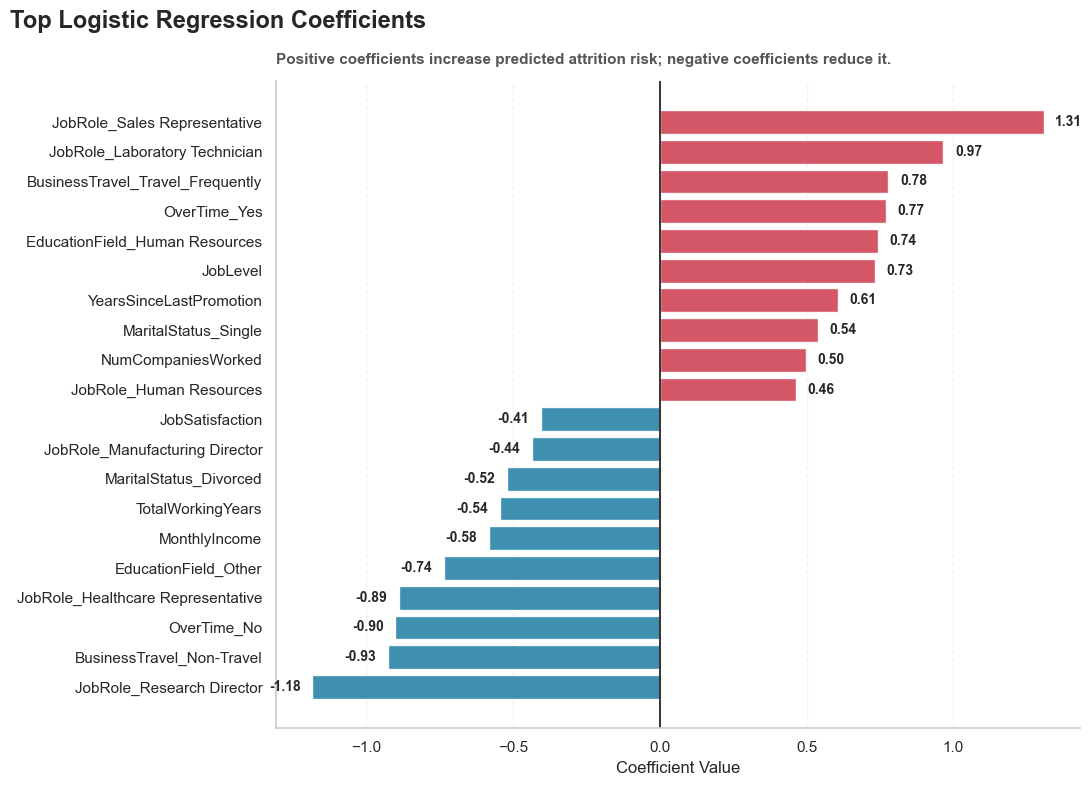

In [70]:
# ==========================================
# Step 54: Visualize top positive and negative coefficients
# ==========================================

# Select top features that increase attrition risk
top_positive_coefficients = (
    coef_df
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

# Select top features that reduce attrition risk
top_negative_coefficients = (
    coef_df
    .sort_values("Coefficient", ascending=True)
    .head(10)
)

# Combine both groups
coef_plot_df = pd.concat(
    [top_negative_coefficients, top_positive_coefficients],
    axis=0
).sort_values("Coefficient")

# Add direction label
coef_plot_df["Direction"] = coef_plot_df["Coefficient"].apply(
    lambda value: "Increases attrition risk" if value > 0 else "Reduces attrition risk"
)

# Create figure
fig, ax = plt.subplots(figsize=(11, 8))

# Colors by direction
colors = coef_plot_df["Direction"].map({
    "Increases attrition risk": "#D1495B",
    "Reduces attrition risk": "#2E86AB"
})

bars = ax.barh(
    coef_plot_df["Feature"],
    coef_plot_df["Coefficient"],
    color=colors,
    alpha=0.92
)

# Add zero line
ax.axvline(
    0,
    color="#333333",
    linewidth=1.4
)

# Add coefficient labels
for bar, value in zip(bars, coef_plot_df["Coefficient"]):
    if value > 0:
        x_position = value + 0.04
        ha = "left"
    else:
        x_position = value - 0.04
        ha = "right"
        
    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=ha,
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Top Logistic Regression Coefficients",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Positive coefficients increase predicted attrition risk; negative coefficients reduce it.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

Conclusion: Logistic Regression Coefficient Chart

The coefficient chart shows which features have the strongest influence on the Logistic Regression model’s attrition predictions.

Positive coefficients increase the model’s prediction toward Attrition = 1, meaning the employee is more likely to leave. Negative coefficients decrease the model’s prediction toward attrition, meaning the employee is more likely to stay.

The strongest risk-increasing feature is JobRole_Sales Representative. This means the model strongly associates Sales Representatives with higher attrition risk. This matches the earlier exploratory analysis, where Sales Representatives had one of the highest attrition rates.

Other features that increase predicted attrition risk include JobRole_Laboratory Technician, BusinessTravel_Travel_Frequently, OverTime_Yes, EducationField_Human Resources, YearsSinceLastPromotion, and MaritalStatus_Single.

The strongest risk-reducing features include JobRole_Research Director, BusinessTravel_Non-Travel, OverTime_No, JobRole_Healthcare Representative, MonthlyIncome, TotalWorkingYears, and JobSatisfaction.

This chart makes the model more interpretable because it explains which features are pushing predictions toward higher or lower attrition risk.

However, these coefficients should be interpreted as model-learned associations, not as proof of direct cause.

# Step 55 — Build scaler comparison pipelines

In [71]:
# ==========================================
# Step 55: Compare StandardScaler, MinMaxScaler, and RobustScaler
# ==========================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Define scalers to compare
scalers_to_compare = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

scaler_model_results = []

for scaler_name, scaler in scalers_to_compare.items():
    
    # Numeric pipeline with selected scaler
    numeric_pipeline_scaler_test = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler)
    ])
    
    # Categorical pipeline remains the same
    categorical_pipeline_scaler_test = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    # Preprocessor
    preprocessor_scaler_test = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline_scaler_test, numeric_features),
            ("categorical", categorical_pipeline_scaler_test, categorical_features)
        ]
    )
    
    # Full model pipeline
    scaler_test_model = Pipeline(steps=[
        ("preprocessor", preprocessor_scaler_test),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])
    
    # Train model
    scaler_test_model.fit(X_train, y_train)
    
    # Predict
    y_pred_scaler = scaler_test_model.predict(X_test)
    y_pred_proba_scaler = scaler_test_model.predict_proba(X_test)[:, 1]
    
    # Store results
    scaler_model_results.append({
        "Scaler": scaler_name,
        "Accuracy": accuracy_score(y_test, y_pred_scaler),
        "Precision": precision_score(y_test, y_pred_scaler),
        "Recall": recall_score(y_test, y_pred_scaler),
        "F1 Score": f1_score(y_test, y_pred_scaler),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba_scaler),
        "PR-AUC": average_precision_score(y_test, y_pred_proba_scaler)
    })

# Convert results to DataFrame
scaler_comparison_df = pd.DataFrame(scaler_model_results)

display(scaler_comparison_df)

,Scaler,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,StandardScaler,0.764,0.372,0.676,0.480,0.816,0.589
1,MinMaxScaler,0.764,0.374,0.690,0.485,0.822,0.594
2,RobustScaler,0.755,0.361,0.676,0.471,0.818,0.592


## Conclusion: Scaler Comparison Experiment

Three scaling techniques were compared using the same Logistic Regression model and the same preprocessing structure:

1. `StandardScaler`
2. `MinMaxScaler`
3. `RobustScaler`

The goal was to test whether changing the scaler improves model performance.

The `MinMaxScaler` model performed slightly better overall. It achieved the highest recall, F1-score, ROC-AUC, and PR-AUC among the three scalers.

Compared with `StandardScaler`, `MinMaxScaler` improved recall from **67.6%** to **69.0%**, F1-score from **48.0%** to **48.5%**, ROC-AUC from **81.6%** to **82.2%**, and PR-AUC from **58.9%** to **59.4%**.

`RobustScaler` performed slightly weaker overall than the other two scalers.

The improvement from `MinMaxScaler` is small, but it is consistent across several important metrics. Therefore, for this Logistic Regression experiment, `MinMaxScaler` is the best scaler among the tested options.

This experiment shows why preprocessing choices should be tested instead of assumed. Different scaling techniques can affect model performance, especially for models such as Logistic Regression.

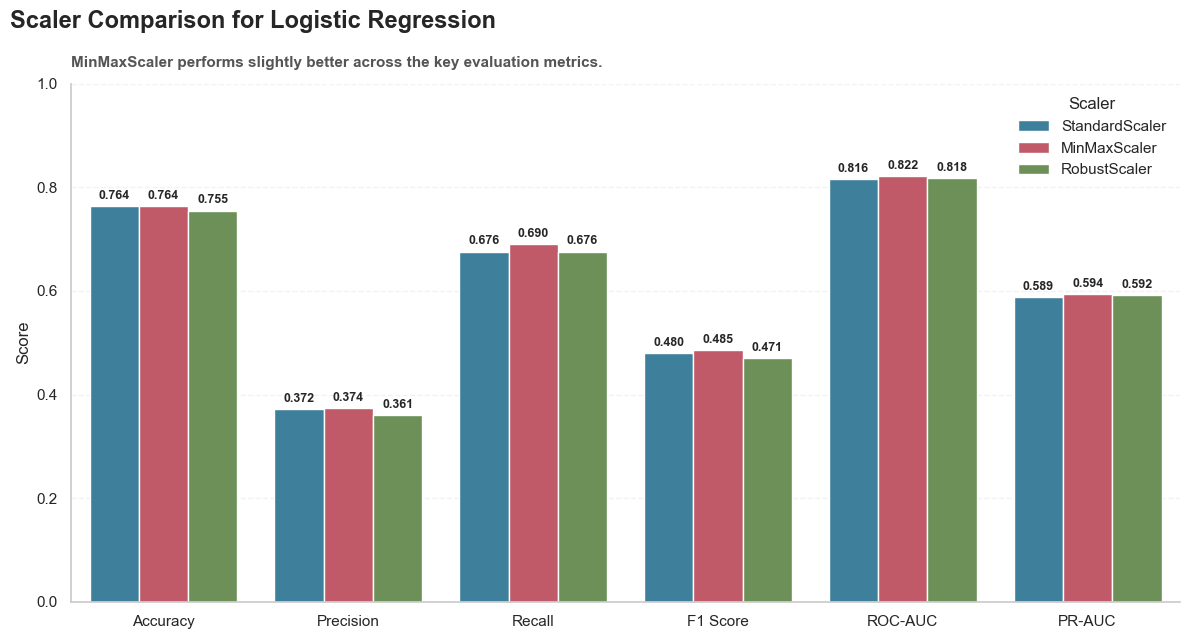

In [72]:
# ==========================================
# Step 56: Visual comparison of scaler performance
# ==========================================

# Convert scaler comparison table into long format
scaler_plot_data = scaler_comparison_df.melt(
    id_vars="Scaler",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"],
    var_name="Metric",
    value_name="Score"
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6.5))

sns.barplot(
    data=scaler_plot_data,
    x="Metric",
    y="Score",
    hue="Scaler",
    palette={
        "StandardScaler": "#2E86AB",
        "MinMaxScaler": "#D1495B",
        "RobustScaler": "#6A994E"
    },
    ax=ax
)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Scaler Comparison for Logistic Regression",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "MinMaxScaler performs slightly better across the key evaluation metrics.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Formatting
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.legend(
    title="Scaler",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

### Conclusion: Scaler Comparison Chart

| Metric   | StandardScaler | MinMaxScaler | Difference |
| -------- | -------------: | -----------: | ---------: |
| Recall   |          0.676 |        0.690 |     +0.014 |
| F1 Score |          0.480 |        0.485 |     +0.005 |
| ROC-AUC  |          0.816 |        0.822 |     +0.006 |
| PR-AUC   |          0.589 |        0.594 |     +0.005 |


The scaler comparison chart shows that MinMaxScaler performs slightly better than StandardScaler and RobustScaler for the Logistic Regression model.

MinMaxScaler achieved the highest recall, F1-score, ROC-AUC, and PR-AUC among the three tested scalers. The improvement is not large, but it is consistent across the most important evaluation metrics.

Recall improved from 67.6% with StandardScaler to 69.0% with MinMaxScaler. This means the model with MinMaxScaler identified slightly more employees who actually left.

F1-score also improved slightly from 48.0% to 48.5%, ROC-AUC improved from 81.6% to 82.2%, and PR-AUC improved from 58.9% to 59.4%.

Based on this experiment, MinMaxScaler is the best scaler for the Logistic Regression model in this project.

This also shows an important machine learning lesson: preprocessing choices should be tested because different scalers can affect model performance.

# Random Forest Model

Now we move to tree-based modeling.

Why Random Forest?

Random Forest is a stronger machine learning model than Logistic Regression in many cases. It combines many decision trees and can capture more complex patterns.

Simple explanation:

One decision tree = one decision-maker
Random Forest = many decision-makers voting together

Important point:

Random Forest does not require scaling like Logistic Regression.

So for Random Forest:

Numeric columns → impute missing values
Categorical columns → one-hot encode
Model → Random Forest

In [73]:
# ==========================================
# Step 57: Random Forest model
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# Numeric pipeline for Random Forest:
# Scaling is not required for tree-based models
numeric_pipeline_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline stays the same
categorical_pipeline_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessor for Random Forest
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_rf, numeric_features),
        ("categorical", categorical_pipeline_rf, categorical_features)
    ]
)

# Random Forest pipeline
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Train Random Forest
random_forest_model.fit(X_train, y_train)

# Predict labels
y_pred_rf = random_forest_model.predict(X_test)

# Predict probabilities for Attrition = 1
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate metrics
random_forest_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_rf),
    "PR-AUC": average_precision_score(y_test, y_pred_proba_rf)
}

random_forest_metrics_df = pd.DataFrame(
    random_forest_metrics.items(),
    columns=["Metric", "Score"]
)

display(random_forest_metrics_df)

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Stayed", "Left"]
))

,Metric,Score
0,Accuracy,0.830
1,Precision,0.423
2,Recall,0.155
3,F1 Score,0.227
4,ROC-AUC,0.776
5,PR-AUC,0.427


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.90       370
        Left       0.42      0.15      0.23        71

    accuracy                           0.83       441
   macro avg       0.64      0.56      0.57       441
weighted avg       0.79      0.83      0.80       441



Conclusion: Random Forest Model

| Metric    | Score |
| --------- | ----: |
| Accuracy  | 0.830 |
| Precision | 0.423 |
| Recall    | 0.155 |
| F1 Score  | 0.227 |
| ROC-AUC   | 0.776 |
| PR-AUC    | 0.427 |


A Random Forest model was trained and evaluated as an additional machine learning model.

The Random Forest achieved an accuracy of 83.0%, which is higher than the Logistic Regression models. However, accuracy is not the most important metric for this project because the dataset is imbalanced.

The recall for employees who left is only 15.5%. This means the Random Forest identified only a small portion of the employees who actually left. In business terms, it missed most of the real leavers.

The model achieved a precision of 42.3%, meaning that when it predicted an employee would leave, it was correct more often than the Logistic Regression model. However, because recall is very low, the model is too conservative and does not flag enough at-risk employees.

For an HR attrition early-warning system, recall is very important because the goal is to identify employees who may leave. Therefore, despite its higher accuracy, the Random Forest model is not better for this specific business problem.

This result shows why model evaluation should not rely only on accuracy. For imbalanced classification problems, recall, F1-score, PR-AUC, and the business objective must be considered.

The Random Forest is mostly predicting employees as Stayed.

It correctly predicts many stayers, so accuracy becomes high. But it misses most employees who actually left.

In HR attrition prediction, this is not good because our main goal is to catch employees at risk of leaving.

From the classification report:

Actual leavers in test set = 71
Recall = 0.155

That means the model only caught about:

11 out of 71 leavers

So it missed around:

60 real leavers
Business interpretation

Random Forest has fewer false alarms, but it misses too many real leavers.

So compared with Logistic Regression:

| Model                              | Recall for Left | Business meaning          |
| ---------------------------------- | --------------: | ------------------------- |
| Logistic Regression + MinMaxScaler |           69.0% | Catches many real leavers |
| Random Forest                      |           15.5% | Misses most real leavers  |


For this HR problem, Logistic Regression is more useful as an early-warning model.

# Tune Random Forest threshold

In [74]:
# ==========================================
# Step 58: Random Forest threshold tuning
# ==========================================

# Test different probability thresholds for Random Forest
thresholds_to_test = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

rf_threshold_results = []

for threshold in thresholds_to_test:
    
    # Convert probabilities into class predictions using custom threshold
    y_pred_rf_threshold = (y_pred_proba_rf >= threshold).astype(int)
    
    rf_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_rf_threshold),
        "Precision": precision_score(y_test, y_pred_rf_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_rf_threshold),
        "F1 Score": f1_score(y_test, y_pred_rf_threshold),
        "Predicted Left Count": int(y_pred_rf_threshold.sum())
    })

rf_threshold_results_df = pd.DataFrame(rf_threshold_results)

display(rf_threshold_results_df)

,Threshold,Accuracy,Precision,Recall,F1 Score,Predicted Left Count
0,0.200,0.728,0.340,0.732,0.464,153
1,0.250,0.800,0.427,0.704,0.532,117
2,0.300,0.821,0.456,0.577,0.509,90
3,0.350,0.825,0.456,0.437,0.446,68
4,0.400,0.830,0.458,0.310,0.370,48
5,0.450,0.832,0.459,0.239,0.315,37
6,0.500,0.830,0.423,0.155,0.227,26


What happened?

At the default threshold:

- Threshold = 0.50
- Recall = 0.155
- F1 Score = 0.227

The model was too conservative. It predicted only 26 employees as likely to leave.

After lowering the threshold:

- Threshold = 0.25
- Recall = 0.704
- F1 Score = 0.532

This is much better.

Best threshold from your table

The best balance appears to be:

- Threshold = 0.25

At threshold 0.25:

| Metric               | Score |
| -------------------- | ----: |
| Accuracy             | 0.800 |
| Precision            | 0.427 |
| Recall               | 0.704 |
| F1 Score             | 0.532 |
| Predicted Left Count |   117 |


### Conclusion: Random Forest Threshold Tuning

The default Random Forest threshold of 0.50 produced high accuracy but very low recall. This means the model predicted most employees as staying and missed many actual leavers.

To improve the model for the HR attrition use case, different probability thresholds were tested.

The best balance was found at a threshold of 0.25. At this threshold, the model achieved an accuracy of 80.0%, precision of 42.7%, recall of 70.4%, and F1-score of 53.2%.

This is a significant improvement over the default threshold. Recall improved from 15.5% to 70.4%, meaning the model identified many more employees who actually left.

The model predicted 117 employees as likely to leave at the 0.25 threshold, which is more suitable for an early-warning HR use case.

This shows that model performance is not only about choosing the algorithm. The classification threshold also matters, especially for imbalanced classification problems.

For this project, the Random Forest model with a threshold of 0.25 is much more useful than the default Random Forest model.

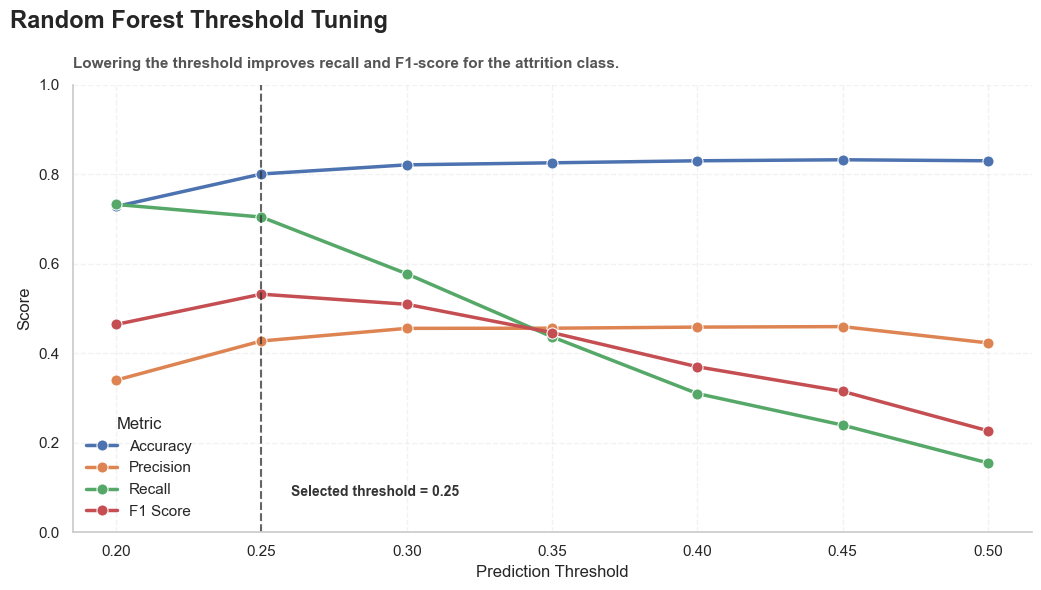

In [75]:
# ==========================================
# Step 59: Visualize Random Forest threshold tuning
# ==========================================

# Convert threshold results into long format
rf_threshold_plot_data = rf_threshold_results_df.melt(
    id_vars="Threshold",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

# Create figure
fig, ax = plt.subplots(figsize=(10.5, 6))

sns.lineplot(
    data=rf_threshold_plot_data,
    x="Threshold",
    y="Score",
    hue="Metric",
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=ax
)

# Highlight selected threshold
selected_threshold = 0.25

ax.axvline(
    selected_threshold,
    color="#333333",
    linestyle="--",
    linewidth=1.5,
    alpha=0.75
)

ax.text(
    selected_threshold + 0.01,
    0.08,
    "Selected threshold = 0.25",
    fontsize=10,
    fontweight="bold",
    color="#333333"
)

# Titles
fig.suptitle(
    "Random Forest Threshold Tuning",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Lowering the threshold improves recall and F1-score for the attrition class.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Prediction Threshold")
ax.set_ylabel("Score")

ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(linestyle="--", alpha=0.25)

ax.legend(
    title="Metric",
    frameon=False,
    loc="best"
)

plt.tight_layout()
plt.show()

## Conclusion: Random Forest Threshold Tuning Chart

The Random Forest threshold tuning chart shows how model performance changes when the prediction threshold is adjusted.

At the default threshold of **0.50**, the Random Forest model is too conservative. It predicts very few employees as likely to leave, which results in a very low recall of **15.5%**.

Lowering the threshold improves recall because the model flags more employees as potential leavers.

The best balance appears at a threshold of **0.25**. At this threshold, the model achieves an accuracy of **80.0%**, precision of **42.7%**, recall of **70.4%**, and F1-score of **53.2%**.

This is much better for the HR attrition use case because the model catches more actual leavers while still maintaining reasonable precision.

This experiment shows that the classification threshold is an important decision in imbalanced classification problems. The default threshold is not always the best choice for the business objective.

# XGBoost model

In [76]:
# ==========================================
# Step 60: Check if XGBoost is installed
# ==========================================

try:
    import xgboost as xgb
    print("XGBoost is installed.")
    print("Version:", xgb.__version__)
except ImportError:
    print("XGBoost is NOT installed.")
    print("Install it by running this in a new notebook cell:")
    print("!pip install xgboost")

XGBoost is NOT installed.
Install it by running this in a new notebook cell:
!pip install xgboost


In [77]:
# ==========================================
# Step 60A: Install XGBoost
# ==========================================

!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.3 MB/s  0:00:00


In [79]:
# ==========================================
# Step 60B: Confirm XGBoost installation
# ==========================================

try:
    import xgboost as xgb
    print("XGBoost is installed.")
    print("Version:", xgb.__version__)
except ImportError:
    print("XGBoost is still not installed.")

XGBoost is installed.
Version: 3.2.0


Important point

XGBoost is tree-based, so like Random Forest:

Scaling is not required

We will use:

Numeric columns → median imputation

Categorical columns → one-hot encoding

Model → XGBoost

In [80]:
# ==========================================
# Step 61: XGBoost model
# ==========================================

from xgboost import XGBClassifier

# Numeric pipeline for XGBoost
# Scaling is not required for tree-based models
numeric_pipeline_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline
categorical_pipeline_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessor for XGBoost
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_xgb, numeric_features),
        ("categorical", categorical_pipeline_xgb, categorical_features)
    ]
)

# Handle class imbalance
# scale_pos_weight = number of stayed employees / number of left employees
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", round(scale_pos_weight_value, 2))

# XGBoost pipeline
xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight_value,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Train model
xgboost_model.fit(X_train, y_train)

# Predict labels
y_pred_xgb = xgboost_model.predict(X_test)

# Predict probabilities for Attrition = 1
y_pred_proba_xgb = xgboost_model.predict_proba(X_test)[:, 1]

# Calculate metrics
xgboost_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_xgb),
    "PR-AUC": average_precision_score(y_test, y_pred_proba_xgb)
}

xgboost_metrics_df = pd.DataFrame(
    xgboost_metrics.items(),
    columns=["Metric", "Score"]
)

display(xgboost_metrics_df)

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Stayed", "Left"]
))

scale_pos_weight: 5.2


,Metric,Score
0,Accuracy,0.821
1,Precision,0.444
2,Recall,0.451
3,F1 Score,0.448
4,ROC-AUC,0.763
5,PR-AUC,0.470


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.89      0.89       370
        Left       0.44      0.45      0.45        71

    accuracy                           0.82       441
   macro avg       0.67      0.67      0.67       441
weighted avg       0.82      0.82      0.82       441



## Conclusion: XGBoost Model


| Metric    | Score |
| --------- | ----: |
| Accuracy  | 0.821 |
| Precision | 0.444 |
| Recall    | 0.451 |
| F1 Score  | 0.448 |
| ROC-AUC   | 0.763 |
| PR-AUC    | 0.470 |

An XGBoost model was trained and evaluated as an advanced tree-based model.

XGBoost achieved an accuracy of **82.1%**, precision of **44.4%**, recall of **45.1%**, F1-score of **44.8%**, ROC-AUC of **76.3%**, and PR-AUC of **47.0%**.

Although the accuracy and precision are reasonable, the recall is lower than the best Logistic Regression and tuned Random Forest models. This means XGBoost missed a larger number of employees who actually left.

For an HR attrition early-warning system, recall is important because the business wants to identify employees who may be at risk of leaving. A model with low recall may look accurate but may fail to catch enough real leavers.

Compared with the tuned Random Forest model at threshold **0.25**, XGBoost performs worse on recall and F1-score. Therefore, XGBoost is not the best model for this project in its current configuration.

This result shows that advanced models do not automatically perform better. Model choice should be based on evaluation metrics and the business objective.

In [81]:
# ==========================================
# Step 62: Final comparison of candidate models
# ==========================================

# Best Logistic Regression from scaler comparison
logreg_minmax_metrics = (
    scaler_comparison_df
    .loc[scaler_comparison_df["Scaler"] == "MinMaxScaler"]
    .drop(columns=["Scaler"])
    .iloc[0]
    .to_dict()
)

# Random Forest default metrics already exist: random_forest_metrics
# Random Forest tuned threshold = 0.25
rf_tuned_025_row = rf_threshold_results_df[
    rf_threshold_results_df["Threshold"] == 0.25
].iloc[0]

random_forest_tuned_metrics = {
    "Accuracy": rf_tuned_025_row["Accuracy"],
    "Precision": rf_tuned_025_row["Precision"],
    "Recall": rf_tuned_025_row["Recall"],
    "F1 Score": rf_tuned_025_row["F1 Score"],
    "ROC-AUC": random_forest_metrics["ROC-AUC"],
    "PR-AUC": random_forest_metrics["PR-AUC"]
}

# Combine final candidates
final_model_comparison_df = pd.DataFrame([
    {"Model": "LogReg + MinMaxScaler", **logreg_minmax_metrics},
    {"Model": "Random Forest Default", **random_forest_metrics},
    {"Model": "Random Forest Threshold 0.25", **random_forest_tuned_metrics},
    {"Model": "XGBoost", **xgboost_metrics}
])

display(final_model_comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,LogReg + MinMaxScaler,0.764,0.374,0.690,0.485,0.822,0.594
1,Random Forest Default,0.830,0.423,0.155,0.227,0.776,0.427
2,Random Forest Threshold 0.25,0.800,0.427,0.704,0.532,0.776,0.427
3,XGBoost,0.821,0.444,0.451,0.448,0.763,0.470


| Model                        | Main strength               | Weakness                                          |
| ---------------------------- | --------------------------- | ------------------------------------------------- |
| LogReg + MinMaxScaler        | Best ROC-AUC and PR-AUC     | Lower F1 than tuned Random Forest                 |
| Random Forest Default        | Highest accuracy            | Very poor recall                                  |
| Random Forest Threshold 0.25 | Best recall and F1-score    | ROC-AUC and PR-AUC lower than Logistic Regression |
| XGBoost                      | Good accuracy and precision | Recall lower than best models                     |


## Conclusion: Final Candidate Model Comparison

Four final candidate models were compared:

1. Logistic Regression with `MinMaxScaler`
2. Random Forest with the default threshold of 0.50
3. Random Forest with a tuned threshold of 0.25
4. XGBoost

The Logistic Regression model with `MinMaxScaler` achieved the best ROC-AUC and PR-AUC scores. This means it has strong overall ranking ability and separates employees who leave from those who stay reasonably well.

The default Random Forest model achieved the highest accuracy at **83.0%**, but its recall was only **15.5%**. This means it missed most employees who actually left, making it unsuitable as an HR early-warning model.

After threshold tuning, the Random Forest model improved significantly. At a threshold of **0.25**, it achieved an accuracy of **80.0%**, precision of **42.7%**, recall of **70.4%**, and F1-score of **53.2%**.

The XGBoost model achieved good accuracy and precision, but its recall of **45.1%** was lower than both Logistic Regression with `MinMaxScaler` and the tuned Random Forest model.

For this HR attrition use case, recall and F1-score are especially important because the business wants to identify employees who may be at risk of leaving. Based on this goal, the **Random Forest model with a threshold of 0.25** is the best final model among the tested options.

This model catches the highest proportion of actual leavers and provides the best balance between precision and recall.

It is also important to note that changing a classification threshold affects metrics such as accuracy, precision, recall, and F1-score. However, ROC-AUC and PR-AUC are based on predicted probabilities, so they remain unchanged when only the threshold is adjusted.

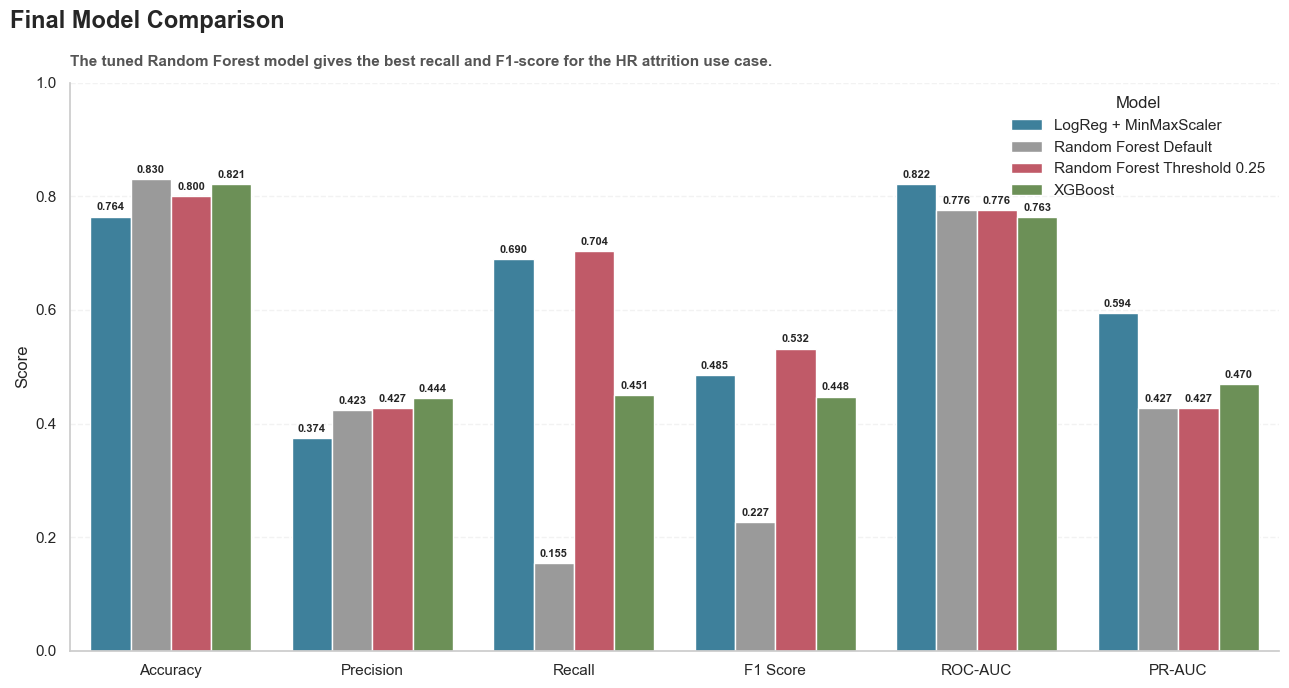

In [82]:
# ==========================================
# Step 63: Visual comparison of final candidate models
# ==========================================

# Convert final model comparison table into long format
final_model_plot_data = final_model_comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"],
    var_name="Metric",
    value_name="Score"
)

# Create figure
fig, ax = plt.subplots(figsize=(13, 7))

sns.barplot(
    data=final_model_plot_data,
    x="Metric",
    y="Score",
    hue="Model",
    palette={
        "LogReg + MinMaxScaler": "#2E86AB",
        "Random Forest Default": "#9A9A9A",
        "Random Forest Threshold 0.25": "#D1495B",
        "XGBoost": "#6A994E"
    },
    ax=ax
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=8,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Final Model Comparison",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "The tuned Random Forest model gives the best recall and F1-score for the HR attrition use case.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Formatting
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.legend(
    title="Model",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

| Model                          | Main result                           |
| ------------------------------ | ------------------------------------- |
| `LogReg + MinMaxScaler`        | Best ROC-AUC and PR-AUC               |
| `Random Forest Default`        | Highest accuracy, but terrible recall |
| `Random Forest Threshold 0.25` | Best recall and best F1-score         |
| `XGBoost`                      | Good precision, but weaker recall     |


## Conclusion: Final Model Comparison Chart

The final model comparison chart summarizes the performance of the strongest candidate models.

The Logistic Regression model with `MinMaxScaler` achieved the best ROC-AUC and PR-AUC scores. This means it has strong probability-ranking ability and separates employees who leave from employees who stay reasonably well.

The default Random Forest model achieved the highest accuracy at **83.0%**, but its recall was only **15.5%**. This means it missed most employees who actually left, so it is not suitable as an HR early-warning model.

The Random Forest model with a tuned threshold of **0.25** achieved the best recall and F1-score. It reached a recall of **70.4%** and an F1-score of **53.2%**. This means it identified the largest share of actual leavers while maintaining the best balance between precision and recall.

The XGBoost model achieved good accuracy and the highest precision, but its recall was lower than the tuned Random Forest and Logistic Regression models.

For this HR attrition use case, recall and F1-score are especially important because the goal is to identify employees who may be at risk of leaving. Based on this business objective, the **Random Forest model with a threshold of 0.25** is selected as the final model.

This result shows that the best model is not always the one with the highest accuracy. The final model should be selected based on the business goal and the most relevant evaluation metrics.

# 📌 Employee Attrition Prediction — Executive Summary

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #60a5fa; border-radius:8px;">

<h2>🎯 Project Objective</h2>

<p>This project analyzed <strong>employee attrition</strong> using the <strong>IBM HR Analytics Employee Attrition dataset</strong>.</p>

<p>The main goals were to:</p>

<ul>
<li>Understand which employee groups are more likely to leave</li>
<li>Identify key business drivers of attrition</li>
<li>Build a machine learning model to detect employees with higher attrition risk</li>
</ul>

</div>

---

## 📊 Dataset Overview

The dataset contains **1,470 employees**.

| Employee Status      |     Count |
| -------------------- | --------: |
| Employees who stayed | **1,233** |
| Employees who left   |   **237** |
| Total employees      | **1,470** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Dataset Insight</h3>

<p>The overall attrition rate is <strong>16.12%</strong>.</p>

<p>This means the dataset is <strong>imbalanced</strong>, because the number of employees who stayed is much higher than the number of employees who left.</p>

</div>

---

# 🔍 Main Business Findings

The exploratory data analysis showed that attrition is **not randomly distributed** across the company.

Several employee groups showed a clearly higher risk of leaving.

## 🚨 High-Risk Employee Groups

The following groups had noticeably higher attrition risk:

* Employees working **overtime**
* **Sales Representatives**
* Younger employees, especially those aged **18–25**
* Employees with **0–1 years** at the company
* Employees with **lower monthly income**
* Employees with poor **work-life balance**
* Employees with low **environment satisfaction**
* Employees who travel frequently for business
* Employees who are **single**

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h2>🧠 Key Business Interpretation</h2>

<p>Attrition risk is concentrated among specific employee segments, especially:</p>

<p><strong>early-career employees, early-tenure employees, overtime employees, frequent travelers, and selected job roles.</strong></p>

</div>

---

# ⚙️ Machine Learning Workflow

A professional preprocessing and modeling workflow was built using **scikit-learn pipelines**.

Several preprocessing and modeling strategies were tested, including:

* Logistic Regression with different scalers
* OneHotEncoder for categorical variables
* Custom feature engineering
* TargetEncoder
* Random Forest
* Random Forest threshold tuning
* XGBoost

## 🧹 Preprocessing Strategy

| Model Type          | Numeric Features     | Categorical Features       |
| ------------------- | -------------------- | -------------------------- |
| Logistic Regression | Imputation + Scaling | Imputation + OneHotEncoder |
| Random Forest       | Imputation only      | Imputation + OneHotEncoder |
| XGBoost             | Imputation only      | Imputation + OneHotEncoder |

For Logistic Regression, three scalers were compared:

* `StandardScaler`
* `MinMaxScaler`
* `RobustScaler`

`MinMaxScaler` performed slightly better than the other scalers for Logistic Regression.

---

# 🤖 Baseline Model

The first baseline model used:

> **OneHotEncoder + Logistic Regression**

Because the dataset is imbalanced, Logistic Regression was trained with:

```python
class_weight="balanced"
```

## 📈 Baseline Model Performance

| Metric    |     Score |
| --------- | --------: |
| Accuracy  | **76.4%** |
| Precision | **37.2%** |
| Recall    | **67.6%** |
| F1-score  | **48.0%** |
| ROC-AUC   | **81.6%** |
| PR-AUC    | **58.9%** |

The baseline model correctly identified about **68% of employees who actually left**, making it useful as an early-warning model.

---

# 📏 Scaler Comparison

Different scaling techniques were tested for Logistic Regression.

The best Logistic Regression version used:

> **MinMaxScaler + OneHotEncoder + Logistic Regression**

This model achieved:

| Metric    |     Score |
| --------- | --------: |
| Accuracy  | **76.4%** |
| Precision | **37.4%** |
| Recall    | **69.0%** |
| F1-score  | **48.5%** |
| ROC-AUC   | **82.2%** |
| PR-AUC    | **59.4%** |

This showed that preprocessing choices can slightly affect model performance.

---

# 🌲 Random Forest and Threshold Tuning

A Random Forest model was also trained.

With the default threshold of **0.50**, Random Forest achieved high accuracy but very low recall. This means it missed many employees who actually left.

To make the model more useful for HR attrition prediction, different classification thresholds were tested.

The best threshold was:

> **0.25**

At this threshold, the Random Forest model achieved:

| Metric    |     Score |
| --------- | --------: |
| Accuracy  | **80.0%** |
| Precision | **42.7%** |
| Recall    | **70.4%** |
| F1-score  | **53.2%** |
| ROC-AUC   | **77.6%** |
| PR-AUC    | **42.7%** |

The tuned Random Forest model identified the highest proportion of actual leavers and achieved the best F1-score among the final candidate models.

---

# ⚡ XGBoost Model

An XGBoost model was also tested as an advanced tree-based model.

It achieved:

| Metric    |     Score |
| --------- | --------: |
| Accuracy  | **82.1%** |
| Precision | **44.4%** |
| Recall    | **45.1%** |
| F1-score  | **44.8%** |
| ROC-AUC   | **76.3%** |
| PR-AUC    | **47.0%** |

Although XGBoost had reasonable accuracy and precision, its recall was lower than the tuned Random Forest and Logistic Regression models. Therefore, it was not selected as the final model.

---

# 🏆 Final Model Choice

The final selected model is:

## ✅ Random Forest with Threshold = 0.25

This model was selected because the main business goal is to identify employees who may be at risk of leaving.

For an HR early-warning system, **recall** and **F1-score** are more important than accuracy alone.

The tuned Random Forest model achieved:

| Metric    |     Score |
| --------- | --------: |
| Accuracy  | **80.0%** |
| Precision | **42.7%** |
| Recall    | **70.4%** |
| F1-score  | **53.2%** |
| ROC-AUC   | **77.6%** |
| PR-AUC    | **42.7%** |

This model catches the largest share of actual leavers while maintaining the best balance between precision and recall.

The final model comparison showed that the best model is not always the model with the highest accuracy. The best model is the one that best supports the business objective.

---

# 💼 Final Business Recommendation

The final Random Forest model with threshold **0.25** can be used as an **HR early-warning tool** to identify employees who may be at higher risk of leaving.

However, the model should **support human decision-making**, not replace it.

Employees flagged by the model should not automatically be treated negatively. Instead, HR teams should use the predictions to support proactive and ethical actions such as:

* Manager check-ins
* Workload review
* Overtime monitoring
* Career development conversations
* Compensation review
* Work-life balance support
* Early-tenure employee support

HR teams should combine model predictions with:

* Business context
* Manager feedback
* Employee conversations
* Ethical considerations
* HR policy judgment

---

# 🚀 Final Takeaway

The best model is not only the most accurate one.

For this project, the best model is the one that provides the most useful balance between:

* Identifying employees who may actually leave
* Avoiding too many false alarms
* Supporting proactive HR decisions
* Remaining understandable and usable for business stakeholders

Based on the final model comparison, the **Random Forest model with threshold 0.25** is the best final model for this HR attrition early-warning use case.
